# asteroid-colmap: test everything

This notebook checks the package from the unit tests up to the finished Vesta RC3 landmark catalog.
Each check prints `✓` (passed) or `✗` (failed). Section 16 lists every check and raises an error if
any failed. The saved outputs come from the full RC3 run, where all 104 checks pass, so the results
can be read without running anything.

| Section | Content |
|---|---|
| 1 | Setup: finds the repository, the workspace and the software versions |
| 2 | Unit tests: the `pytest` suite |
| 3–6 | Building blocks: the Dawn FC2 camera model, the PDS labels, the Vesta rotation model and the catalog helpers |
| 7 | Pipeline (optional): downloads the images and runs every step again |
| 8–11 | Results: catalog invariants, camera alignment, duplicate keypoints, and label-poses mode against incremental mode |
| 12–13 | Figures: every figure, and the interactive point cloud |
| 14–15 | Navigation: NCC matching of new images to the catalog, and the relative pose from those matches |
| 16 | Summary of all checks |

**Data.** The notebook reads the workspace named by the environment variable
`ASTEROID_COLMAP_WORKDIR`, or `work/` in the repository when that variable is not set.

* If the workspace has no catalog, the notebook uses the results committed in `examples/vesta_rc3`.
  That folder holds only the curated subset, so the checks that need `landmarks.csv` or
  `observations.csv` are skipped (81 checks run instead of 104), and the committed figures are shown
  instead of redrawn.
* Section 11 compares the two mapping modes directly only when an incremental-mode catalog is
  in `ASTEROID_COLMAP_OTHER` or `work_inc/`. Otherwise it checks the comparison stored in
  `examples/vesta_rc3`.
* Section 13 needs plotly (`pip install -e ".[interactive]"`).
* Sections 14–15 read `$WORKDIR/navigation`, or else `examples/vesta_rc3/navigation`. The
  maplet checks need `catalog/templates.npz` and the per-match checks need `matches.csv`;
  neither is committed (74 MB and 103 MB).

**Rebuilding.** Set `RUN_PIPELINE = True` in the first code cell to download the RC3 images
(540 MB) and run the label-poses pipeline into the workspace. This needs COLMAP and takes about
5 minutes on a laptop CPU, plus the download. It does not run incremental mode: the README section
"Validation: two independent mapping modes" shows how. Set `RUN_NAVIGATION = True` to build
the maplets, download the 15 OPNAV_022 images (60 MB) and redo sections 14–15: about 3 minutes
plus the download, on top of a finished catalog.

## 1. Setup

In [1]:
import io
import json
import os
import platform
import re
import subprocess
import sys
import tempfile
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

RUN_PIPELINE = False  # True: download the RC3 images and run every step into WORKDIR
MAX_IMAGES = None     # with RUN_PIPELINE: e.g. 30 for a quicker, sparser run
RUN_NAVIGATION = False  # True: build the maplets, download OPNAV_022 and redo sections 14-15 into WORKDIR
NAV_RUNS = {
    "opnav022": "15 new images from 2011-07-31, a week after RC3 (not in the catalog)",
    "catalog": "the 130 catalog images, each matched without its own reference views",
}

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)


def find_repo(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists() and (p / "src" / "asteroid_colmap").is_dir():
            return p
    raise FileNotFoundError("start the notebook from inside the asteroid-colmap repository")


REPO = find_repo(Path.cwd().resolve())
WORKDIR = Path(os.environ.get("ASTEROID_COLMAP_WORKDIR", REPO / "work")).resolve()
OTHER = Path(os.environ.get("ASTEROID_COLMAP_OTHER", WORKDIR.with_name(WORKDIR.name + "_inc"))).resolve()
EXAMPLE = REPO / "examples" / "vesta_rc3"
sys.path.insert(0, str(REPO / "src"))  # test this checkout, even if pip installed another copy


def rel(path) -> str:
    # path for printing: relative to the repository, $WORKDIR or $OTHER, never absolute
    path = Path(path).resolve()
    for root, tag in ((REPO, "."), (WORKDIR, "$WORKDIR"), (OTHER, "$OTHER")):
        if path.is_relative_to(root):
            return f"{tag}/{path.relative_to(root).as_posix()}".removesuffix("/.")
    return path.name


CHECKS = []
SECTION = "setup"


def check(name, ok, detail=""):
    # record one check and print it
    status = "pass" if ok else "FAIL"
    CHECKS.append({"section": SECTION, "check": name, "status": status, "detail": detail})
    print("✓" if ok else "✗", name, f"({detail})" if detail else "")


has_catalog = (WORKDIR / "catalog" / "landmarks.csv").exists()
print("work dir  ", rel(WORKDIR), "(catalog found)" if has_catalog else "(no catalog: examples/vesta_rc3 is used)")
print("second run", rel(OTHER), "(catalog found)" if (OTHER / "catalog" / "landmarks.csv").exists() else "(not found)")

work dir   ./work (catalog found)
second run ./work_inc (not found)


In [2]:
from asteroid_colmap.reconstruct import colmap_executable, colmap_version


def pkg_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"


try:
    colmap = colmap_version(colmap_executable())
except FileNotFoundError:
    colmap = "not found (needed only to run the pipeline)"

packages = ["asteroid-colmap", "numpy", "scipy", "pandas", "matplotlib", "astropy", "pillow", "plotly", "pytest"]
display(pd.Series({"python": platform.python_version(), **{p: pkg_version(p) for p in packages}, "COLMAP": colmap},
                  name="version").to_frame())

import asteroid_colmap

here = Path(asteroid_colmap.__file__).resolve().parent
ok = here == REPO / "src" / "asteroid_colmap"
check("asteroid_colmap is imported from this repository", ok,
      rel(here) if ok else f"{here}: restart the kernel, or `pip install -e .` from this folder")

,version
python,3.13.2
asteroid-colmap,0.1.0
numpy,2.5.1
scipy,1.18.1
pandas,3.0.6
matplotlib,3.11.2
astropy,8.0.1
pillow,12.3.0
plotly,7.1.0
pytest,9.1.1


✓ asteroid_colmap is imported from this repository (./src/asteroid_colmap)


## 2. Unit tests

The suite in `tests/` covers the label parser, the geometry, the camera model, COLMAP model I/O,
pair selection, the catalog helpers and the reconstruction options. It needs no data and no COLMAP.

In [3]:
SECTION = "unit tests"
res = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider", "tests"],
                     cwd=REPO, capture_output=True, text=True)
lines = res.stdout.strip().splitlines()
if res.returncode:
    print(res.stdout[-5000:], res.stderr[-2000:])
check("pytest suite", res.returncode == 0, lines[-1] if lines else "no output")

✓ pytest suite (59 passed in 2.01s)


## 3. Camera model

The Dawn FC2 camera with filter F1 is a pinhole camera with one radial distortion term, taken from
the NAIF instrument kernel and written as COLMAP's `OPENCV` model. The checks:

* `pixel_rays` and `project` must invert each other.
* The field of view must match the nominal value from the focal length and the pixel pitch.
* The distortion must be small: below a pixel at the image corner.
* The focal length is about 10.5 image widths, which is above COLMAP's sanity limit of 10.
  Left alone, COLMAP silently refuses to triangulate from such a camera, so the pipeline raises
  the limit.

In [4]:
SECTION = "camera"
from asteroid_colmap.camera import get_camera
from asteroid_colmap.config import VESTA, get_dataset
from asteroid_colmap.reconstruct import _camera_limits

ds = get_dataset("vesta-rc3")
cam = get_camera(ds.camera)
print(cam)
print(f"COLMAP {cam.colmap_model}: {cam.colmap_params_str()}")
print(f"IFOV {cam.ifov_rad * 1e6:.2f} µrad, i.e. {cam.ifov_rad * 5500:.3f} km/px at 5,500 km")

rng = np.random.default_rng(0)
u, v = rng.uniform(0, cam.width, 10_000), rng.uniform(0, cam.height, 10_000)
rays = cam.pixel_rays(u, v)
uv = cam.project(5500.0 * rays)
err = np.hypot(uv[:, 0] - u, uv[:, 1] - v).max()
check("pixel_rays returns unit vectors", np.allclose(np.linalg.norm(rays, axis=1), 1.0))
check("project(pixel_rays(u, v)) = (u, v)", err < 1e-3, f"max {err:.1e} px over 10,000 random pixels")

edges = cam.pixel_rays(np.array([0.0, cam.width]), np.array([cam.cy, cam.cy]))
fov = np.degrees(np.arccos(edges[0] @ edges[1]))
nominal = 2 * np.degrees(np.arctan(cam.width * cam.pixel_pitch_mm[0] / 2 / cam.focal_length_mm))
check("horizontal field of view", abs(fov / nominal - 1) < 2e-3, f"{fov:.3f}° (nominal {nominal:.3f}°)")

corner = cam.pixel_rays(np.array([0.0]), np.array([0.0]))[0]
pinhole = np.array([cam.fx * corner[0] / corner[2] + cam.cx, cam.fy * corner[1] / corner[2] + cam.cy])
r_dist, r_pin = np.hypot(cam.cx, cam.cy), np.hypot(*(pinhole - [cam.cx, cam.cy]))
check("radial distortion is sub-pixel", abs(r_dist - r_pin) < 1.0,
      f"{r_dist - r_pin:+.2f} px = {100 * (r_dist / r_pin - 1):.3f} % at the corner")

ratio = max(cam.fx, cam.fy) / max(cam.width, cam.height)
limit = _camera_limits(cam)["Mapper.max_focal_length_ratio"]
check("focal length / width exceeds COLMAP's default limit of 10", ratio > 10, f"{ratio:.2f}")
check("the pipeline raises the limit above it", limit > ratio, f"Mapper.max_focal_length_ratio = {limit:.1f}")

FramingCamera(name='Dawn FC2, filter 1 (clear)', focal_length_mm=150.07, pixel_pitch_mm=(0.014004, 0.013995), center_px=(511.5, 511.5), radial_e1_per_mm2=8.4e-06, width=1024, height=1024)
COLMAP OPENCV: 10716.22394,10723.1154,512,512,0.1891764412,0,0,0
IFOV 93.32 µrad, i.e. 0.513 km/px at 5,500 km
✓ pixel_rays returns unit vectors 
✓ project(pixel_rays(u, v)) = (u, v) (max 3.0e-09 px over 10,000 random pixels)
✓ horizontal field of view (5.468° (nominal 5.471°))
✓ radial distortion is sub-pixel (+0.62 px = 0.086 % at the corner)
✓ focal length / width exceeds COLMAP's default limit of 10 (10.47)
✓ the pipeline raises the limit above it (Mapper.max_focal_length_ratio = 20.9)


## 4. PDS labels

The first label in `$WORKDIR/raw` is used if the images were downloaded. Otherwise the notebook
uses the trimmed copy of the first RC3 label that the unit tests use. The label record also
checks the rotation model: the sub-spacecraft point computed from the label's J2000 position
must land on the label's own sub-spacecraft latitude and longitude.

In [5]:
SECTION = "labels"
from asteroid_colmap import metadata, pds

raw_labels = sorted((WORKDIR / "raw").glob("*/*.LBL"))
if raw_labels:
    lbl_path, source = raw_labels[0], rel(raw_labels[0])
else:
    sys.path.insert(0, str(REPO / "tests"))
    from conftest import LABEL_TEXT

    lbl_path = Path(tempfile.mkdtemp()) / "2011205_RC3" / "FC21B0003112_11205060002F1C.LBL"
    lbl_path.parent.mkdir()
    lbl_path.write_text(LABEL_TEXT, encoding="latin-1")
    source = "tests/conftest.py (trimmed copy of the first RC3 label)"

lab = pds.read_label(lbl_path)
utc = metadata.parse_time(lab)
print(f"{source}: {len(lab)} keywords, START_TIME = {utc.isoformat()} UTC")
keys = ["INSTRUMENT_ID", "OBSERVATION_ID", "FILTER_NUMBER", "EXPOSURE_DURATION", "QUATERNION",
        "SC_TARGET_POSITION_VECTOR", "SUB_SPACECRAFT_LATITUDE", "SUB_SPACECRAFT_LONGITUDE", "PHASE_ANGLE"]
display(pd.Series({k: lab.get(k) for k in keys}, name="value").to_frame())

q = np.asarray(lab["QUATERNION"], float)
check("QUATERNION is a unit 4-vector", q.shape == (4,) and abs(np.linalg.norm(q) - 1) < 1e-6)
check("START_TIME is in RC3 (2011, day 205)", (utc.year, utc.timetuple().tm_yday) == (2011, 205))

rec = metadata.label_record(lbl_path, VESTA)
check("rotation model reproduces the label's sub-spacecraft point", rec["rotation_model_check_deg"] < 1e-3,
      f"{rec['rotation_model_check_deg'] * 3600:.2f} arcsec")

./work/raw/2011205_RC3/FC21B0003112_11205060002F1C.LBL: 168 keywords, START_TIME = 2011-07-24T06:00:02.137000 UTC


,value
INSTRUMENT_ID,FC2
OBSERVATION_ID,FC2_VSA_RC3
FILTER_NUMBER,1
EXPOSURE_DURATION,8.0
QUATERNION,"(0.1744357085, -0.3431161973, -0.9079719753, 0.1656211065)"
SC_TARGET_POSITION_VECTOR,"(1102.517, -2285.015, -4857.051)"
SUB_SPACECRAFT_LATITUDE,15.197632
SUB_SPACECRAFT_LONGITUDE,-58.343917
PHASE_ANGLE,42.713278


✓ QUATERNION is a unit 4-vector 
✓ START_TIME is in RC3 (2011, day 205) 
✓ rotation model reproduces the label's sub-spacecraft point (2.27 arcsec)


## 5. Rotation model and quaternions

Vesta's body-fixed frame is Claudia double-prime: the IAU pole and spin rate, with the prime
meridian moved to the Claudia crater convention.

In [6]:
SECTION = "rotation model"
from asteroid_colmap import geometry as geo

R = geo.body_from_j2000(VESTA, utc)
check("body_from_j2000 is a proper rotation", np.allclose(R @ R.T, np.eye(3), atol=1e-12) and np.isclose(np.linalg.det(R), 1.0))
pole = geo.latlon_to_unit(VESTA.pole_dec_deg, VESTA.pole_ra_deg)
check("body +z axis is the IAU pole", np.allclose(R.T @ [0.0, 0.0, 1.0], pole, atol=1e-12),
      f"RA {VESTA.pole_ra_deg}°, Dec {VESTA.pole_dec_deg}°")
period_h = 360.0 / VESTA.w_rate_deg_per_day * 24
check("sidereal rotation period", abs(period_h - 5.342) < 1e-3, f"{period_h:.4f} h")

worst = 0.0
for qi in rng.normal(size=(1000, 4)):
    qi /= np.linalg.norm(qi)
    q2 = geo.matrix_to_quat(geo.quat_to_matrix(qi))
    worst = max(worst, min(np.abs(qi - q2).max(), np.abs(qi + q2).max()))
check("quaternion → matrix → quaternion (up to sign)", worst < 1e-12, f"max error {worst:.1e} over 1,000 random rotations")

✓ body_from_j2000 is a proper rotation 
✓ body +z axis is the IAU pole (RA 309.031°, Dec 42.235°)
✓ sidereal rotation period (5.3421 h)
✓ quaternion → matrix → quaternion (up to sign) (max error 6.7e-16 over 1,000 random rotations)


## 6. Catalog helpers

* **Grades.** A landmark gets grade A or B when it meets all three thresholds in `GRADES`
  (track length, triangulation angle, reprojection error), and C otherwise.
* **Equal-area cells.** The curated subset keeps one landmark per cell of about 10 km × 10 km.
  For 400,000 random points on a sphere, the cell count must match the area ratio, and the
  scatter of the points per cell must be pure Poisson noise. Any extra scatter would mean
  unequal cells.
* **Pixel frames.** The FITS arrays are stored bottom-up, so the prepared PNGs are flipped
  up-down (`ud`). `pixel_frames` maps COLMAP pixels back to the stored FITS rows.

In [7]:
SECTION = "catalog helpers"
from asteroid_colmap.catalog import GRADES, equal_area_cells, grade, pixel_frames

(nA, angA, errA), (nB, angB, errB) = GRADES["A"], GRADES["B"]
cases = pd.DataFrame(
    [("exactly at the A thresholds", nA, angA, errA, "A"),
     ("A, but one image short", nA - 1, angA, errA, "B"),
     ("A, but error 0.01 px too high", nA, angA, errA + 0.01, "B"),
     ("exactly at the B thresholds", nB, angB, errB, "B"),
     ("B, but angle 0.01° too small", nB, angB - 0.01, errB, "C"),
     ("wide angle, small error, only 3 images", 3, 60.0, 0.1, "C")],
    columns=["case", "track", "tri_angle_deg", "error_px", "expected"])
cases["grade"] = grade(cases.track.to_numpy(), cases.tri_angle_deg.to_numpy(), cases.error_px.to_numpy())
display(cases)
check("grade() at the threshold edges", (cases.grade == cases.expected).all())

R_MEAN = float(np.mean(VESTA.radii_km))
p = rng.normal(size=(400_000, 3))
lat, lon, _ = geo.cart_to_latlonr(p / np.linalg.norm(p, axis=1, keepdims=True))
counts = pd.Series(equal_area_cells(lat, lon, 10.0, R_MEAN)).value_counts()
n_cells = 4 * np.pi * R_MEAN**2 / 10.0**2
check("10 km cells tile the sphere", abs(len(counts) / n_cells - 1) < 0.01, f"{len(counts):,} cells, 4πR²/s² = {n_cells:,.0f}")
scatter = counts.std() / np.sqrt(counts.mean())
check("cells have equal area", scatter < 1.1, f"std / √mean of points per cell = {scatter:.2f}; 1 for Poisson noise")

f = pixel_frames(np.array([0.5, cam.width - 0.5]), np.array([0.5, cam.height - 0.5]), "ud", cam)
check("'ud' flip: the first PNG row is the last FITS row",
      np.allclose(f["line_ik"], [0, cam.height - 1]) and np.allclose(f["fits_row"], [cam.height - 1, 0])
      and np.allclose(f["fits_col"], f["sample_ik"]))

,case,track,tri_angle_deg,error_px,expected,grade
0,exactly at the A thresholds,8,15.00,1.00,A,A
1,"A, but one image short",7,15.00,1.00,B,B
2,"A, but error 0.01 px too high",8,15.00,1.01,B,B
3,exactly at the B thresholds,4,5.00,2.00,B,B
4,"B, but angle 0.01° too small",4,4.99,2.00,C,C
5,"wide angle, small error, only 3 images",3,60.00,0.10,C,C


✓ grade() at the threshold edges 
✓ 10 km cells tile the sphere (8,674 cells, 4πR²/s² = 8,672)
✓ cells have equal area (std / √mean of points per cell = 1.00; 1 for Poisson noise)
✓ 'ud' flip: the first PNG row is the last FITS row 


## 7. Pipeline (optional)

With `RUN_PIPELINE = True`, this cell runs `asteroid-colmap run -w WORKDIR`. That downloads the
RC3 images and labels (about 540 MB), then prepares the images, runs COLMAP, builds the catalog
and draws the figures. Otherwise the existing results are used.

In [8]:
SECTION = "pipeline"
if RUN_PIPELINE:
    from asteroid_colmap import cli

    argv = ["run", "-w", str(WORKDIR)] + (["--max-images", str(MAX_IMAGES)] if MAX_IMAGES else [])
    status = cli.main(argv)
    check("asteroid-colmap run", status == 0, f"exit status {status}")
else:
    print("RUN_PIPELINE is False: using the existing results")

RUN_PIPELINE is False: using the existing results


## 8. Catalog invariants

These checks recompute what each column of the catalog promises from the other columns:

* coordinates against `x/y/z`;
* height against the ellipsoid;
* grades against `GRADES`;
* the outlier flag;
* the ground sample distance;
* the ID order;
* the curated subset, checked against its scoring rule:
  track length × min(triangulation angle, 30°) / max(error, 0.2 px), best per cell.

With only the committed examples, the checks run on the curated subset.

In [9]:
SECTION = "catalog"
CAT = WORKDIR / "catalog"
FULL = (CAT / "landmarks.csv").exists()
SRC = CAT if FULL else EXAMPLE
curated = pd.read_csv(SRC / "landmarks_curated.csv")
cams = pd.read_csv(SRC / "cameras.csv")
summary = json.loads((SRC / "summary.json").read_text())
lm = pd.read_csv(CAT / "landmarks.csv") if FULL else curated
obs = pd.read_csv(CAT / "observations.csv") if FULL else None
print(f"reading {rel(SRC)}:", "full catalog" if FULL else "curated subset only (landmarks.csv and observations.csv are not committed)")

al = summary["alignment"]
grades = " / ".join(f"{summary['grades'].get(g, 0):,}" for g in "ABC")
display(pd.Series({
    "registered images": f"{summary['num_registered_images']} of {summary['num_input_images']}",
    "landmarks (A / B / C)": f"{summary['num_landmarks']:,} ({grades})",
    "curated landmarks": f"{summary['num_curated_landmarks']:,} (one per {summary.get('curated_spacing_km') or 10:g} km cell)",
    "observations": f"{summary['num_observations']:,}",
    "median track length": f"{summary['median_track_length']:.0f} images",
    "median reprojection error": f"{summary['median_reproj_error_px']:.3f} px",
    "median triangulation angle": f"{summary['median_tri_angle_deg']:.1f}°",
    "height p05 / p50 / p95": " / ".join(f"{h:+.2f}" for h in summary["height_km_p05_p50_p95"]) + " km",
    "camera position RMS vs labels": f"{al['position_rms_km']:.2f} km",
    "… along the line of sight / sideways": f"{al['position_range_rms_km']:.2f} / {al['position_lateral_rms_km']:.2f} km",
    "attitude median vs labels": f"{al['attitude_median_deg']:.4f}°",
    "landmark offset under the label poses": f"{summary['label_pointing_offset_median_px']:.2f} px (median)",
}, name="RC3").to_frame())

reading ./work/catalog: full catalog


,RC3
registered images,130 of 130
landmarks (A / B / C),"94,543 (33,946 / 40,972 / 19,625)"
curated landmarks,"7,480 (one per 10 km cell)"
observations,"823,792"
median track length,6 images
median reprojection error,0.238 px
median triangulation angle,34.5°
height p05 / p50 / p95,-9.75 / -0.87 / +8.29 km
camera position RMS vs labels,2.22 km
… along the line of sight / sideways,1.10 / 1.93 km


In [10]:
MAX_HEIGHT_KM = 60.0  # default of `asteroid-colmap catalog --max-height`
xyz = lm[["x_km", "y_km", "z_km"]].to_numpy()
radius = np.linalg.norm(xyz, axis=1)
direction = geo.latlon_to_unit(lm.lat_deg.to_numpy(), lm.lon_deg.to_numpy())
ell = geo.ellipsoid_radius(lm.lat_deg, lm.lon_deg, VESTA.radii_km)

check("landmark IDs are unique LMK_nnnnnn", lm.landmark_id.is_unique and lm.landmark_id.str.fullmatch(r"LMK_\d{6}").all(),
      f"{len(lm):,} landmarks")
check("lat/lon/radius match x/y/z",
      np.abs(direction - xyz / radius[:, None]).max() < 1e-6 and np.abs(radius - lm.radius_km).max() < 1e-5)
check("ellipsoid_radius_km and height_km", np.abs(ell - lm.ellipsoid_radius_km).max() < 1e-5
      and np.abs(lm.radius_km - ell - lm.height_km).max() < 1e-5)
regrade = grade(lm.track_length.to_numpy(), lm.max_tri_angle_deg.to_numpy(), lm.reproj_error_px.to_numpy())
n_bad = int((regrade != lm.grade.to_numpy()).sum())
check("grades follow GRADES", n_bad <= 1e-4 * len(lm), f"{n_bad} mismatches; 0.01 % allowed for CSV rounding")
check("outlier = |height| > 60 km", (lm.outlier == (lm.height_km.abs() > MAX_HEIGHT_KM)).all(), f"{int(lm.outlier.sum())} outliers")
check("gsd_km = mean range × IFOV", np.allclose(lm.gsd_km, lm.mean_range_km * cam.ifov_rad, rtol=1e-5, atol=2e-6),
      f"median {lm.gsd_km.median():.3f} km/px")
check("IDs follow quality order (outliers last, then grade)",
      lm.landmark_id.is_monotonic_increasing and lm.outlier.is_monotonic_increasing
      and lm[~lm.outlier].grade.is_monotonic_increasing)

spacing = summary.get("curated_spacing_km") or 10.0
cells = equal_area_cells(curated.lat_deg, curated.lon_deg, spacing, R_MEAN)
check("curated: grades A/B only, no outliers", curated.grade.isin(["A", "B"]).all() and not curated.outlier.any())
check("curated: at most one landmark per cell", pd.Series(cells).is_unique, f"{len(curated):,} landmarks, {spacing:g} km cells")
check("summary.json: curated count", summary["num_curated_landmarks"] == len(curated))

if FULL:
    check("curated ⊂ landmarks", curated.landmark_id.isin(lm.landmark_id).all())
    good = lm[~lm.outlier & lm.grade.isin(["A", "B"])].copy()
    good["cell"] = equal_area_cells(good.lat_deg, good.lon_deg, spacing, R_MEAN)
    good["score"] = good.track_length * np.minimum(good.max_tri_angle_deg, 30.0) / np.maximum(good.reproj_error_px, 0.2)
    best = good.groupby("cell").score.max()
    picked = good[good.landmark_id.isin(curated.landmark_id)]
    ties = int(good.groupby("cell").score.apply(lambda s: (s == s.max()).sum() > 1).sum())
    check("curated covers every cell with an A/B candidate", set(picked.cell) == set(best.index),
          f"{len(best):,} cells")
    check("each curated landmark has its cell's best score",
          np.allclose(picked.score, best.reindex(picked.cell), rtol=1e-6),
          f"{ties} cells have a tie for best; either landmark is valid")
    check("summary.json: landmark, grade, outlier and observation counts",
          summary["num_landmarks"] == len(lm) and summary["grades"] == lm.grade.value_counts().to_dict()
          and summary["num_outliers"] == int(lm.outlier.sum()) and summary["num_observations"] == len(obs))

✓ landmark IDs are unique LMK_nnnnnn (94,543 landmarks)
✓ lat/lon/radius match x/y/z 
✓ ellipsoid_radius_km and height_km 
✓ grades follow GRADES (0 mismatches; 0.01 % allowed for CSV rounding)
✓ outlier = |height| > 60 km (3 outliers)
✓ gsd_km = mean range × IFOV (median 0.493 km/px)
✓ IDs follow quality order (outliers last, then grade) 
✓ curated: grades A/B only, no outliers 
✓ curated: at most one landmark per cell (7,480 landmarks, 10 km cells)
✓ summary.json: curated count 
✓ curated ⊂ landmarks 
✓ curated covers every cell with an A/B candidate (7,480 cells)
✓ each curated landmark has its cell's best score (185 cells have a tie for best; either landmark is valid)
✓ summary.json: landmark, grade, outlier and observation counts 


### Observations

`observations.csv` has one row per landmark measurement in one image (full catalog only). The
checks tie it back to the track lengths, to the per-image counts and reprojection RMS in
`cameras.csv`, and to the image flip.

In [11]:
if FULL:
    reg = cams[cams.registered]
    per_lm = obs.groupby("landmark_id").size()
    check("track_length = observations per landmark", per_lm.reindex(lm.landmark_id).eq(lm.track_length.to_numpy()).all(),
          f"{len(obs):,} observations")
    per_img = obs.groupby("image").size()
    check("num_landmarks = observations per image", np.array_equal(per_img.reindex(reg.image).to_numpy(), reg.num_landmarks.to_numpy()))
    rms = np.sqrt((obs.residual_u_px**2 + obs.residual_v_px**2).groupby(obs.image).mean())
    check("reproj_rms_px = RMS of the image's residuals", np.allclose(rms.reindex(reg.image), reg.reproj_rms_px, atol=1e-3),
          f"median {reg.reproj_rms_px.median():.3f} px")
    flip = summary["image_flip"]
    frames = pixel_frames(obs.u.to_numpy(), obs.v.to_numpy(), flip, cam)
    worst = max(np.abs(frames[c] - obs[c].to_numpy()).max() for c in frames)
    check(f"IK and FITS pixel columns follow the '{flip}' flip", worst < 1e-3, f"max {worst:.1e} px")
else:
    print("observations.csv not available: skipped")

✓ track_length = observations per landmark (823,792 observations)
✓ num_landmarks = observations per image 
✓ reproj_rms_px = RMS of the image's residuals (median 0.673 px)
✓ IK and FITS pixel columns follow the 'ud' flip (max 1.1e-13 px)


## 9. Cameras and alignment

The model is aligned to the label poses with a similarity transform. These checks recompute the
summary statistics from the per-image rows of `cameras.csv`. They also cross-check two label
quantities against the rotation model and the camera:

* The sub-spacecraft point must agree with the rotation model.
* The label's pixel scale must equal (range − surface radius) × IFOV.

At 5,500 km with a 5.5° field of view the camera residuals are kilometres, because two motions
barely change the image: a sideways shift with the camera turned to keep Vesta centred, and a
move along the line of sight. So each position residual is also split into its range part
(`position_range_km`, positive when COLMAP is farther from the body) and its sideways part
(`position_east_km`, `position_north_km`, length `position_lateral_km`). The image-space measure
is `label_offset_px`: the median distance, in each image, between where the label pose projects
the landmarks and where they are measured.

In [12]:
SECTION = "cameras"
reg = cams[cams.registered]
used = reg[reg.used_in_fit.astype(bool)]
check("cameras.csv lists every input image", len(cams) == summary["num_input_images"], f"{len(cams)} images")
check("at least 90 % of images registered", len(reg) == summary["num_registered_images"] and len(reg) >= 0.9 * len(cams),
      f"{len(reg)} of {len(cams)}")
check("rotation model vs every label's sub-spacecraft point", cams.rotation_model_check_deg.max() < 1e-3,
      f"max {cams.rotation_model_check_deg.max() * 3600:.2f} arcsec")
surface = geo.ellipsoid_radius(cams.subsc_lat_deg, cams.subsc_lon_deg, VESTA.radii_km)
scale_err = ((cams.range_km - surface) * cam.ifov_rad / cams.pixel_scale_km - 1).abs().max()
check("label pixel scale = (range − surface radius) × IFOV", scale_err < 5e-3,
      f"max {100 * scale_err:.2f} %; the label gives 3 decimals")

rms = float(np.sqrt((used.position_residual_km**2).mean()))
check("position RMS recomputed = summary", abs(rms - al["position_rms_km"]) < 1e-3, f"{rms:.3f} km")
check("camera positions agree with the labels (RMS < 5 km)", rms < 5.0,
      f"{rms:.2f} km = {100 * rms / reg.range_km.median():.3f} % of the range")
att = float(reg.attitude_residual_deg.median())
check("attitude median recomputed = summary", abs(att - al["attitude_median_deg"]) < 1e-5, f"{att:.4f}°")
check("attitudes agree with the labels (median < 0.05°)", att < 0.05, f"{np.radians(att) / cam.ifov_rad:.1f} px")
bore = float(np.hypot(reg.boresight_du_px, reg.boresight_dv_px).median())
check("boresight median recomputed = summary", abs(bore - al["boresight_median_px"]) < 1e-3, f"{bore:.2f} px")
check("model is neither mirrored nor reversed", not al["mirrored_or_reversed"])

if "position_range_km" in reg:
    split = np.sqrt(reg.position_range_km**2 + reg.position_east_km**2 + reg.position_north_km**2)
    err = float((split - reg.position_residual_km).abs().max())
    check("range² + east² + north² = residual²", err < 1e-4, f"max {err:.1e} km")
    err = float((np.hypot(reg.position_east_km, reg.position_north_km) - reg.position_lateral_km).abs().max())
    check("position_lateral_km = √(east² + north²)", err < 1e-4, f"max {err:.1e} km")
    los = float(np.sqrt((used.position_range_km**2).mean()))
    side = float(np.sqrt((used.position_lateral_km**2).mean()))
    check("line-of-sight and sideways RMS recomputed = summary",
          max(abs(los - al["position_range_rms_km"]), abs(side - al["position_lateral_rms_km"])) < 1e-3,
          f"{los:.3f} km line of sight, {side:.3f} km sideways")
    err = float((np.hypot(reg.label_offset_u_px, reg.label_offset_v_px) - reg.label_offset_px).abs().max())
    check("label_offset_px = √(u² + v²)", err < 1e-4, f"max {err:.1e} px")
    lab = float(reg.label_offset_px.median())
    by_seq = reg.groupby("sequence")[["label_offset_u_px", "label_offset_v_px"]].median()
    stored = pd.DataFrame(summary["label_pointing_offset_by_sequence_px"], index=by_seq.columns).T
    seq_err = float((by_seq - stored.loc[by_seq.index]).abs().to_numpy().max())
    check("landmark offset under the label poses recomputed = summary",
          abs(lab - summary["label_pointing_offset_median_px"]) < 1e-3 and seq_err < 1e-3,
          f"{lab:.2f} px median; per sequence (u, v) " + ", ".join(
              f"{s} ({u:+.2f}, {v:+.2f})" for s, (u, v) in by_seq.iterrows()))
    check("the label poses fit the landmarks to a few pixels (median < 5 px)", lab < 5.0,
          f"{lab:.2f} px = {lab * np.degrees(cam.ifov_rad) * 3600:.0f}″, against a {bore:.1f} px boresight difference")
else:
    print("cameras.csv has no position split: re-run `asteroid-colmap catalog` with this version")

✓ cameras.csv lists every input image (130 images)
✓ at least 90 % of images registered (130 of 130)
✓ rotation model vs every label's sub-spacecraft point (max 2.43 arcsec)
✓ label pixel scale = (range − surface radius) × IFOV (max 0.29 %; the label gives 3 decimals)
✓ position RMS recomputed = summary (2.218 km)
✓ camera positions agree with the labels (RMS < 5 km) (2.22 km = 0.040 % of the range)
✓ attitude median recomputed = summary (0.0225°)
✓ attitudes agree with the labels (median < 0.05°) (4.2 px)
✓ boresight median recomputed = summary (3.81 px)
✓ model is neither mirrored nor reversed 
✓ range² + east² + north² = residual² (max 1.1e-06 km)
✓ position_lateral_km = √(east² + north²) (max 9.5e-07 km)
✓ line-of-sight and sideways RMS recomputed = summary (1.101 km line of sight, 1.926 km sideways)
✓ label_offset_px = √(u² + v²) (max 9.8e-07 px)
✓ landmark offset under the label poses recomputed = summary (2.41 px median; per sequence (u, v) RC3 (-2.07, -0.95), RC3B (+0.65, -2.58

## 10. Duplicate keypoints

SIFT gives a keypoint with two dominant gradient directions a second orientation, and stores it
as a second keypoint at the same pixel. The two copies can be matched into different tracks,
which turns one surface feature into two landmarks a few hundred metres apart. COLMAP's
covariant extractor, used for DSP-SIFT, ignores `SiftExtraction.max_num_orientations`, so the
package removes the copies from the database after extraction
(`reconstruct.drop_duplicate_keypoints`). COLMAP can also put two distinct keypoints of one
image, a few pixels apart, in the same track; the catalog keeps the one closer to the projection
(`catalog.one_observation_per_image`).

This cell checks that:

* no image in the feature database has two keypoints at the same pixel;
* no two landmarks share a keypoint (same image, same pixel);
* no landmark is observed twice in one image.

In [13]:
SECTION = "duplicate keypoints"
db = WORKDIR / "colmap" / "database.db"
if db.exists():
    import sqlite3
    from contextlib import closing
    with closing(sqlite3.connect(db.as_uri() + "?mode=ro", uri=True)) as con:
        rows = con.execute("SELECT rows, cols, data FROM keypoints").fetchall()
    n_kp = sum(n for n, _, _ in rows)
    repeats = sum(n - len(np.unique(np.frombuffer(data, np.float32).reshape(n, cols)[:, :2], axis=0))
                  for n, cols, data in rows if n)
    check("database: one keypoint per pixel", repeats == 0,
          f"{repeats:,} repeats among {n_kp:,} keypoints in {len(rows)} images")
else:
    print(rel(db), "not found: database check skipped")
if FULL:
    kp = obs[["landmark_id", "image", "u", "v"]]
    same_image = int(kp.duplicated(["landmark_id", "image"]).sum())
    shared = kp[kp.duplicated(["image", "u", "v"], keep=False)]
    pairs = (shared.merge(shared, on=["image", "u", "v"]).query("landmark_id_x < landmark_id_y")
             .drop_duplicates(["landmark_id_x", "landmark_id_y"]))
    check("no two landmarks share a keypoint", len(pairs) == 0,
          f"{len(shared):,} of {len(kp):,} observations share a pixel; {len(pairs):,} landmark pairs")
    check("no landmark is observed twice in one image", same_image == 0, f"{same_image:,} repeated observations")
else:
    print("observations.csv not available: skipped")

✓ database: one keypoint per pixel (0 repeats among 996,733 keypoints in 130 images)
✓ no two landmarks share a keypoint (0 of 823,792 observations share a pixel; 0 landmark pairs)
✓ no landmark is observed twice in one image (0 repeated observations)


## 11. Label-poses mode vs incremental mode

The default `label-poses` mode triangulates with the camera poses fixed to the labels. The
`incremental` mode lets COLMAP solve everything from scratch. `compare_catalogs` pairs the
landmarks of two runs by the keypoints they share, then measures the 3-D differences. Once the
small mean offset between the two models is removed, the matched landmarks should agree in
position and height to a small fraction of a pixel footprint. The incremental mode never uses the
label poses, so it should also find the same per-sequence offset of the landmarks under those poses:
that offset is a bias of the label pointing, not of the catalog.

When the incremental-mode catalog is in `ASTEROID_COLMAP_OTHER` or `work_inc/`, this cell compares
the two catalogs directly. Otherwise it checks the stored RC3 comparison,
`examples/vesta_rc3/compare_incremental.json`.

In [14]:
SECTION = "mode comparison"
from asteroid_colmap.catalog import compare_catalogs

if FULL and (OTHER / "catalog" / "observations.csv").exists():
    print(f"comparing {rel(CAT)} with {rel(OTHER / 'catalog')}")
    cmp = compare_catalogs(CAT, OTHER / "catalog")
else:
    cmp_path = EXAMPLE / "compare_incremental.json"
    print(f"second catalog not found: checking the stored RC3 comparison {rel(cmp_path)}")
    cmp = json.loads(cmp_path.read_text())
nan2 = [np.nan, np.nan]  # compare_catalogs leaves the statistics out when nothing matched
n_a, n_b = cmp["num_landmarks"]
frac = cmp["num_matched"] / max(min(n_a, n_b), 1)
p50, p90 = cmp.get("distance_minus_offset_km_p50_p90", nan2)
offset = float(np.linalg.norm(cmp.get("mean_offset_km", nan2)))
dh50, dh90 = cmp.get("height_difference_km_p50_absp90", nan2)
gsd = float(cams.pixel_scale_km.median())
display(pd.Series({
    "landmarks (label-poses / incremental)": f"{n_a:,} / {n_b:,}",
    "matched": f"{cmp['num_matched']:,} ({100 * frac:.1f} % of the smaller catalog)",
    "3-D distance p50 / p90 / p99": " / ".join(f"{1000 * d:.0f}" for d in cmp.get("distance_km_p50_p90_p99", [np.nan] * 3)) + " m",
    "mean offset": f"{1000 * offset:.0f} m",
    "distance after removing the offset, p50 / p90": f"{1000 * p50:.0f} / {1000 * p90:.0f} m",
    "height difference, median / |p90|": f"{1000 * dh50:+.0f} / {1000 * dh90:.0f} m",
    "pixel footprint (median label pixel scale)": f"{1000 * gsd:.0f} m",
}, name="comparison").to_frame())

check("most landmarks are found in both modes", frac > 0.85, f"{100 * frac:.1f} %")
check("matched landmarks agree after removing the offset", p50 < 0.1 * gsd, f"p50 {1000 * p50:.0f} m < 10 % of a pixel footprint")
check("mean offset is below one pixel footprint", offset < gsd, f"{1000 * offset:.0f} m")
check("matched landmarks agree in height", abs(dh50) < 0.1 * gsd and dh90 < gsd,
      f"median {1000 * dh50:+.0f} m, |p90| {1000 * dh90:.0f} m < one pixel footprint")

other_summary = OTHER / "catalog" / "summary.json"
if not (FULL and other_summary.exists()):
    other_summary = EXAMPLE / "summary_incremental.json"
key = "label_pointing_offset_by_sequence_px"
mine, theirs = summary.get(key), json.loads(other_summary.read_text()).get(key)
if mine and theirs and set(mine) == set(theirs):
    gap = max(abs(x - y) for s in mine for x, y in zip(mine[s], theirs[s]))
    check("both modes find the same label pointing offset per sequence", gap < 0.25,
          f"max difference {gap:.2f} px; " + ", ".join(
              f"{s} ({mine[s][0]:+.2f}, {mine[s][1]:+.2f}) vs ({theirs[s][0]:+.2f}, {theirs[s][1]:+.2f})" for s in mine))
else:
    print(f"{rel(other_summary)} has no {key}: skipped")

second catalog not found: checking the stored RC3 comparison ./examples/vesta_rc3/compare_incremental.json


,comparison
landmarks (label-poses / incremental),"94,576 / 94,331"
matched,"92,292 (97.8 % of the smaller catalog)"
3-D distance p50 / p90 / p99,98 / 124 / 1993 m
mean offset,100 m
"distance after removing the offset, p50 / p90",16 / 46 m
"height difference, median / |p90|",+12 / 96 m
pixel footprint (median label pixel scale),486 m


✓ most landmarks are found in both modes (97.8 %)
✓ matched landmarks agree after removing the offset (p50 16 m < 10 % of a pixel footprint)
✓ mean offset is below one pixel footprint (100 m)
✓ matched landmarks agree in height (median +12 m, |p90| 96 m < one pixel footprint)
✓ both modes find the same label pointing offset per sequence (max difference 0.17 px; RC3 (-2.07, -0.95) vs (-1.98, -0.99), RC3B (+0.65, -2.58) vs (+0.82, -2.52))


## 12. Figures

With a full workspace, `make_all` redraws every figure into `$WORKDIR/plots`. The house style
is applied inside each plot call only, so your matplotlib settings must be unchanged afterwards.
Without a workspace, the committed figures from `examples/vesta_rc3/plots` are shown.
The figures are embedded as reduced JPEG copies to keep the notebook small.

✓ make_all leaves matplotlib's rcParams unchanged 
✓ all 11 figures drawn (11 PNGs in ./work/plots)


**02_geometry**: sub-spacecraft ground track with the polar-night band; range and phase against hours since sequence start

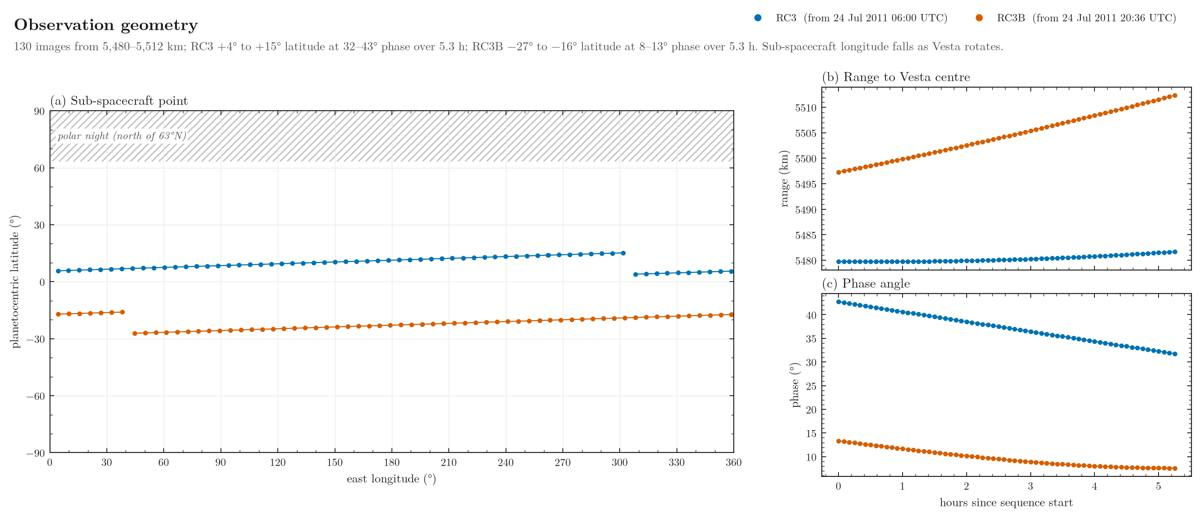

**01_montage**: prepared input frames, evenly spaced in time

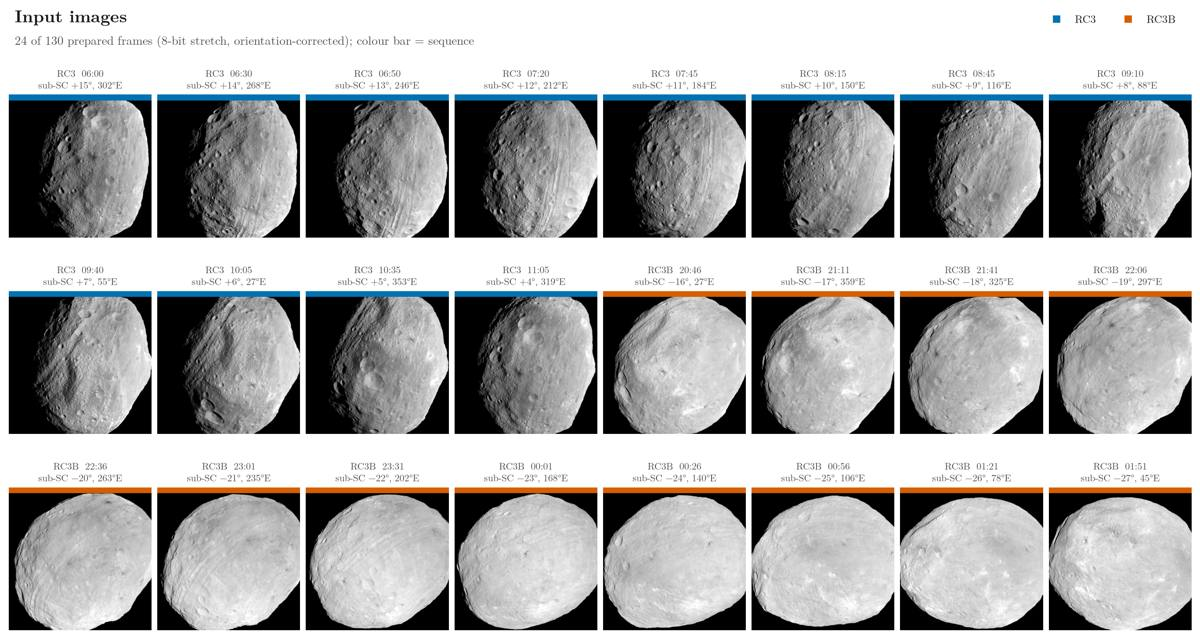

**03_orientation_check**: observed silhouettes against the label-predicted lit ellipsoid, for every flip

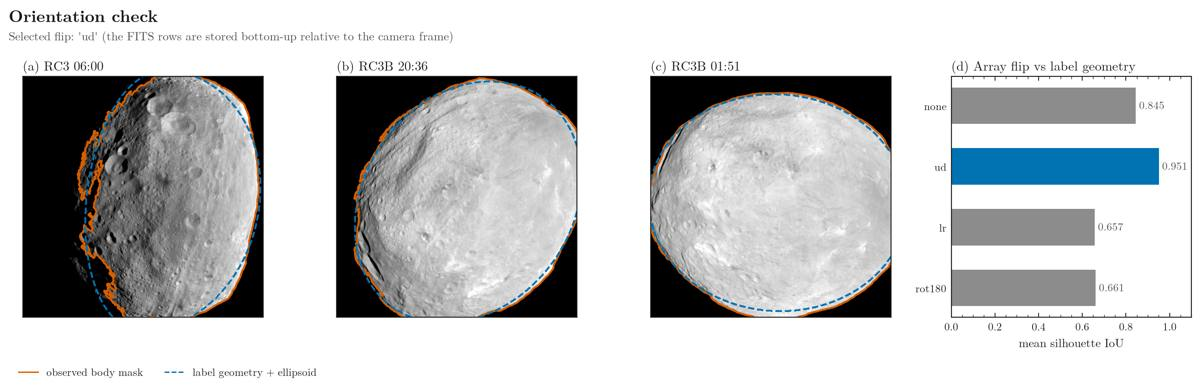

**04_features**: landmark observations on the best-connected image of each sequence

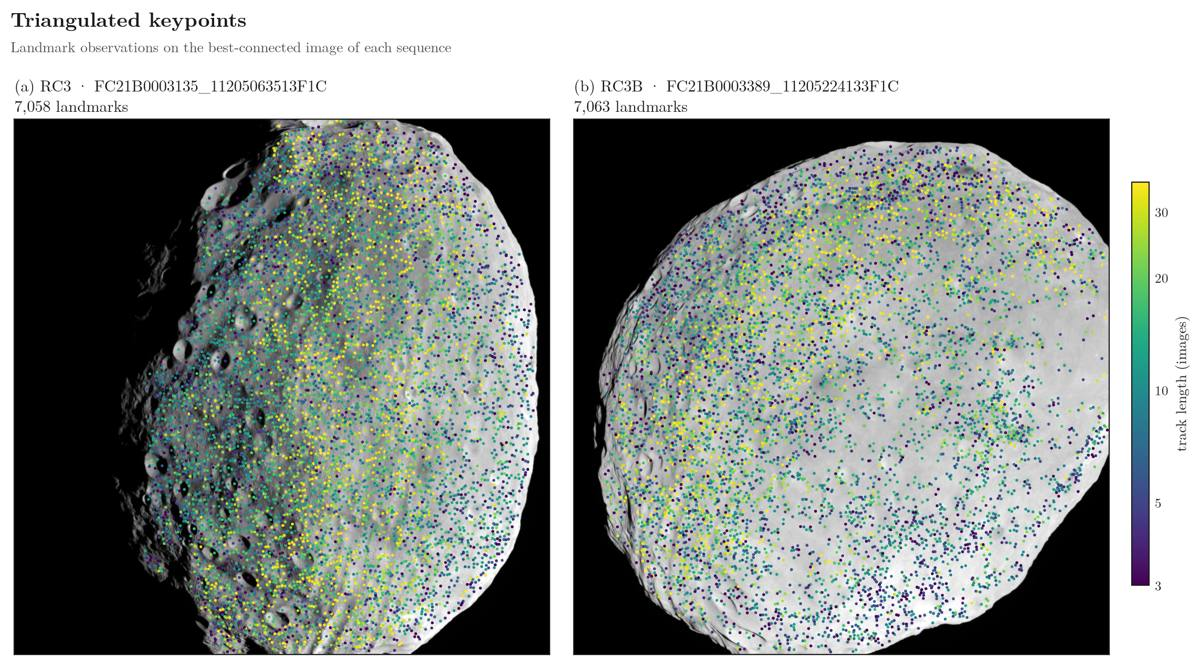

**05_covisibility**: landmarks shared by every image pair

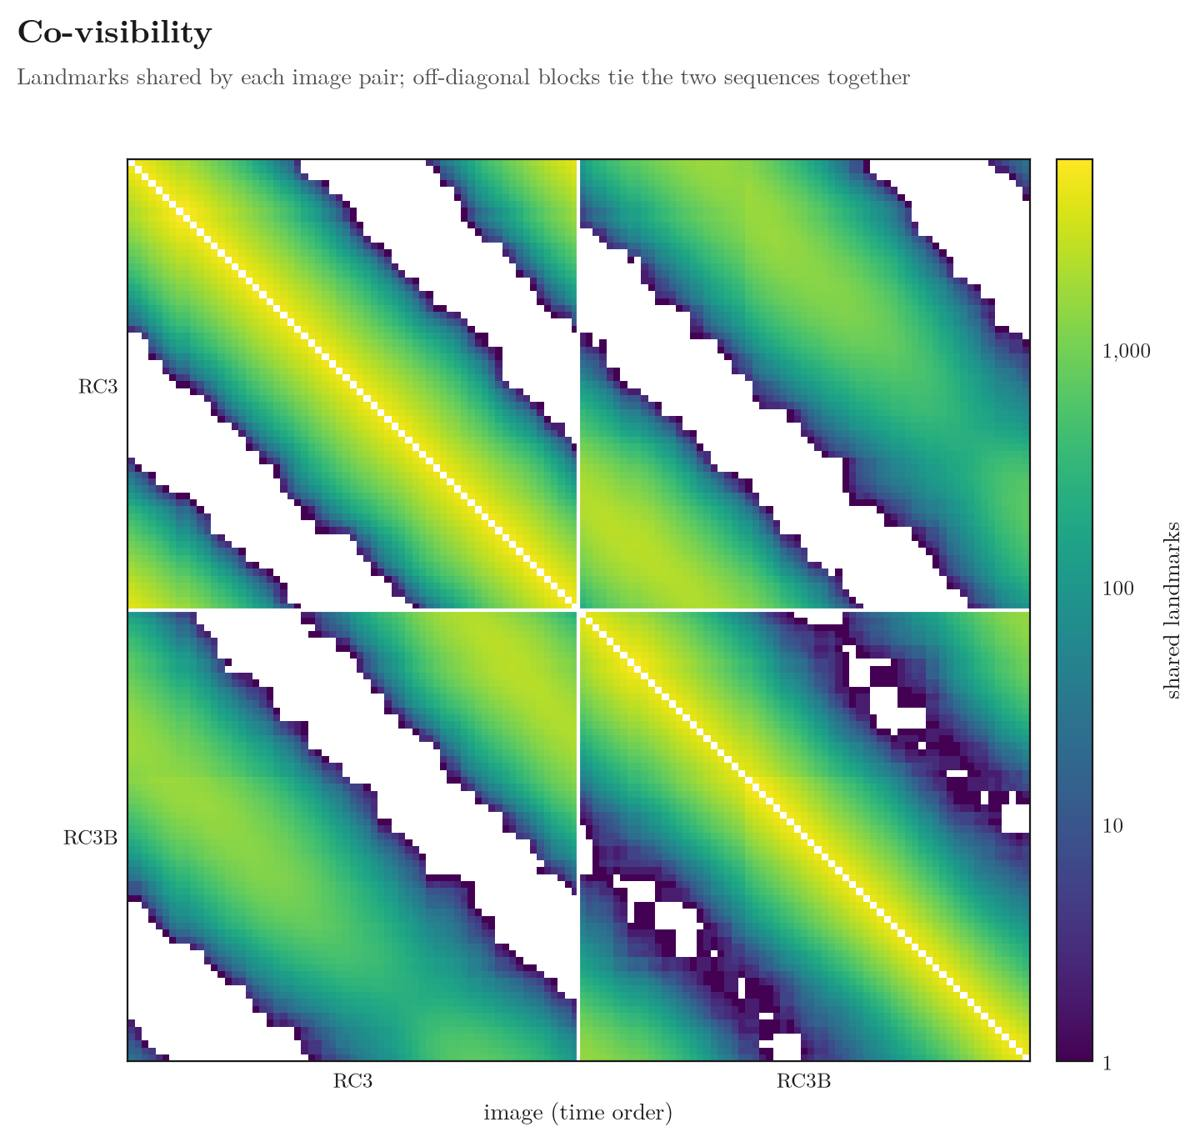

**06_alignment**: per image, relative to the label poses: position residual along the line of sight and sideways, pointing difference at the boresight and at the landmarks, and twist

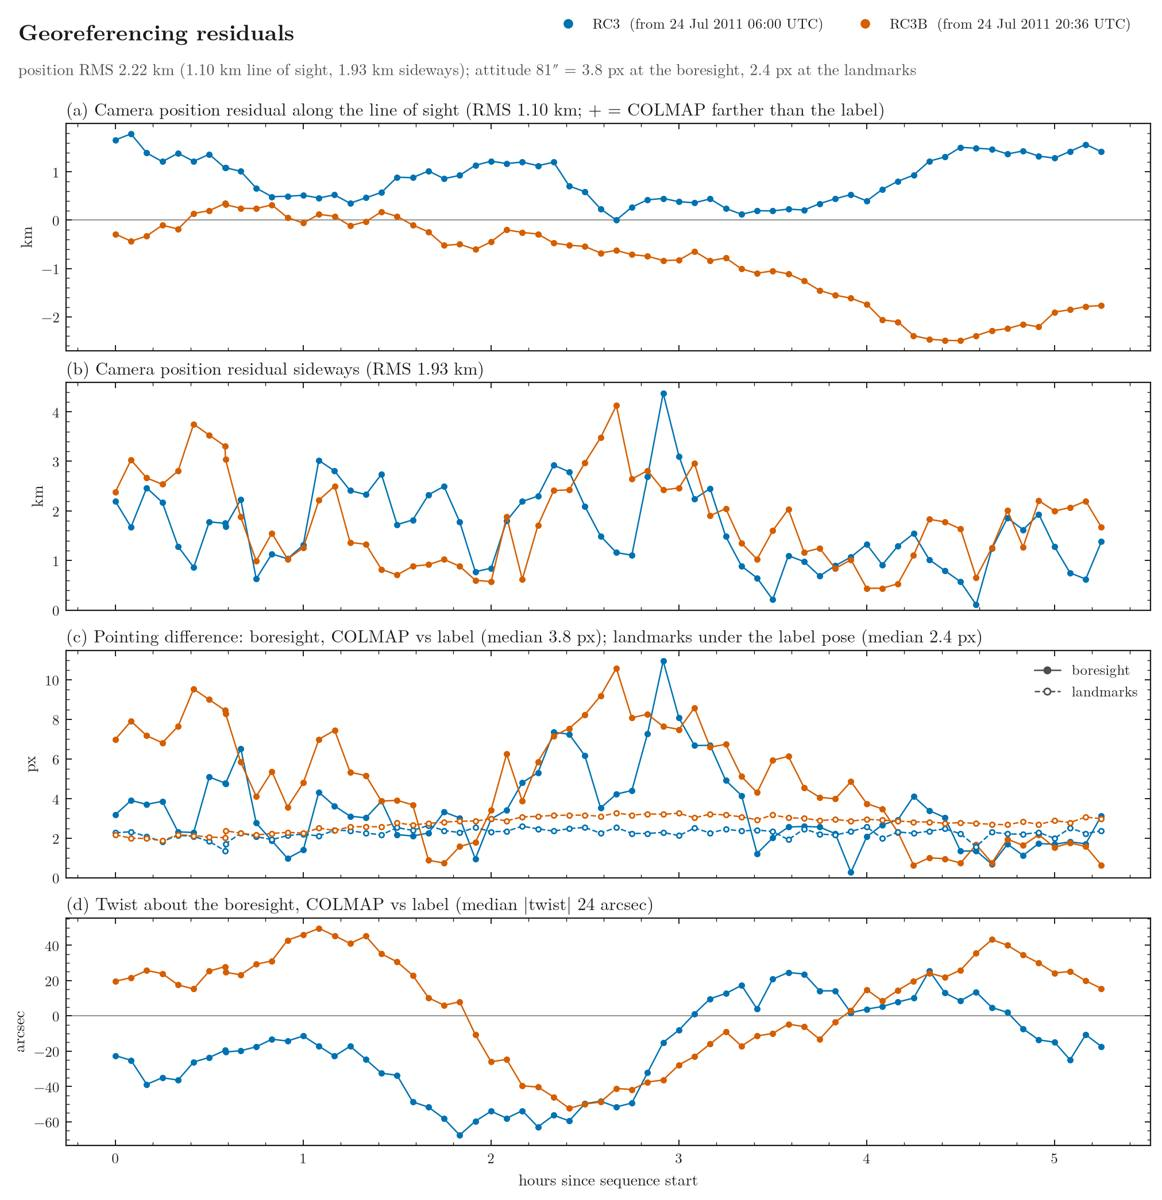

**07_pointcloud**: four orthographic globe views of the landmarks, coloured by height

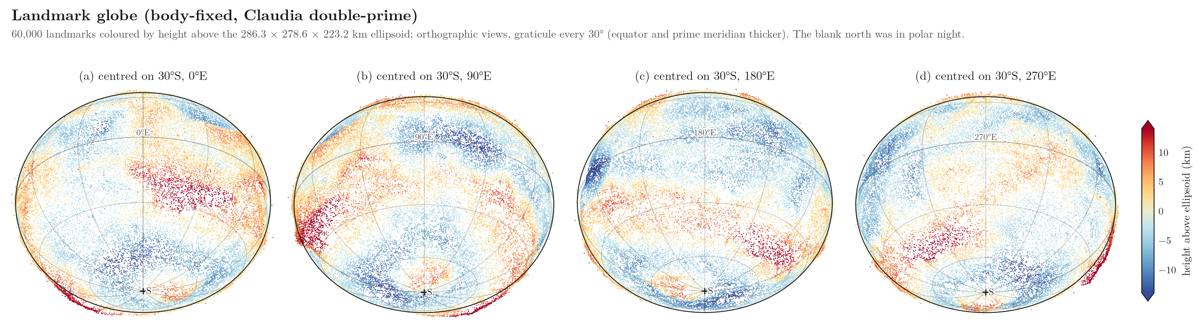

**08_landmark_map**: equirectangular map by height, curated subset by track length, south-polar view of Rheasilvia

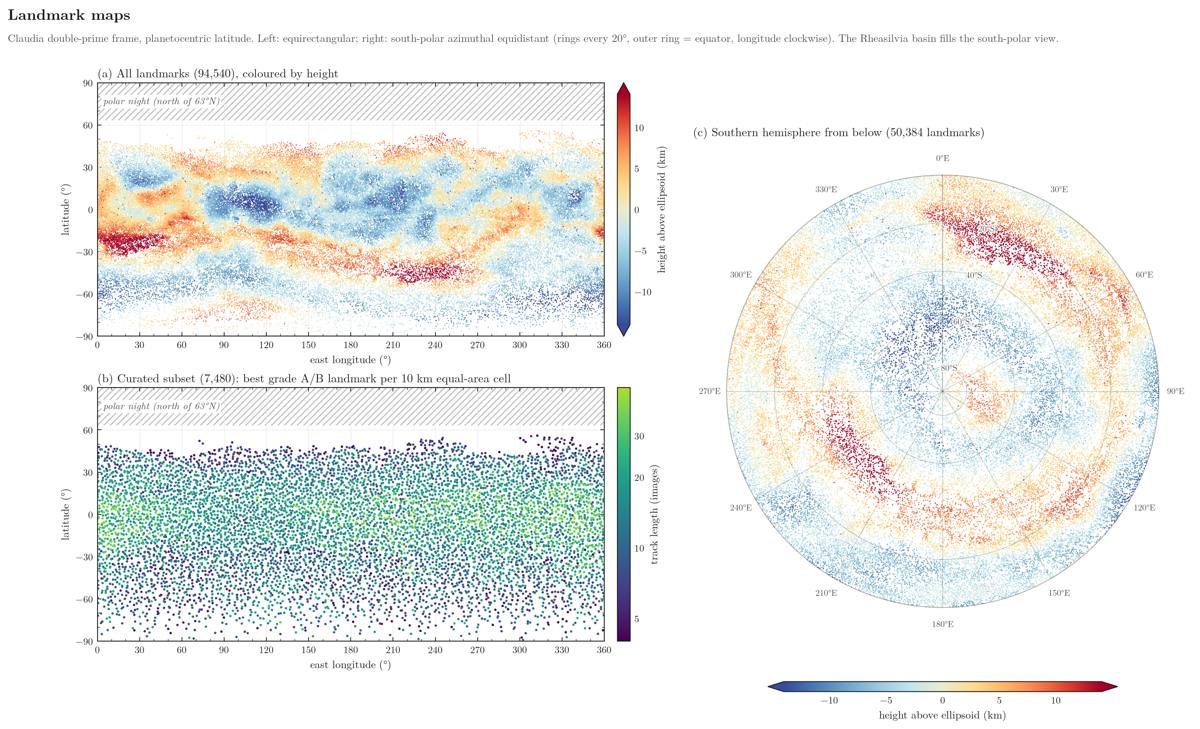

**09_quality**: track length, reprojection error, triangulation angle and height, stacked by grade

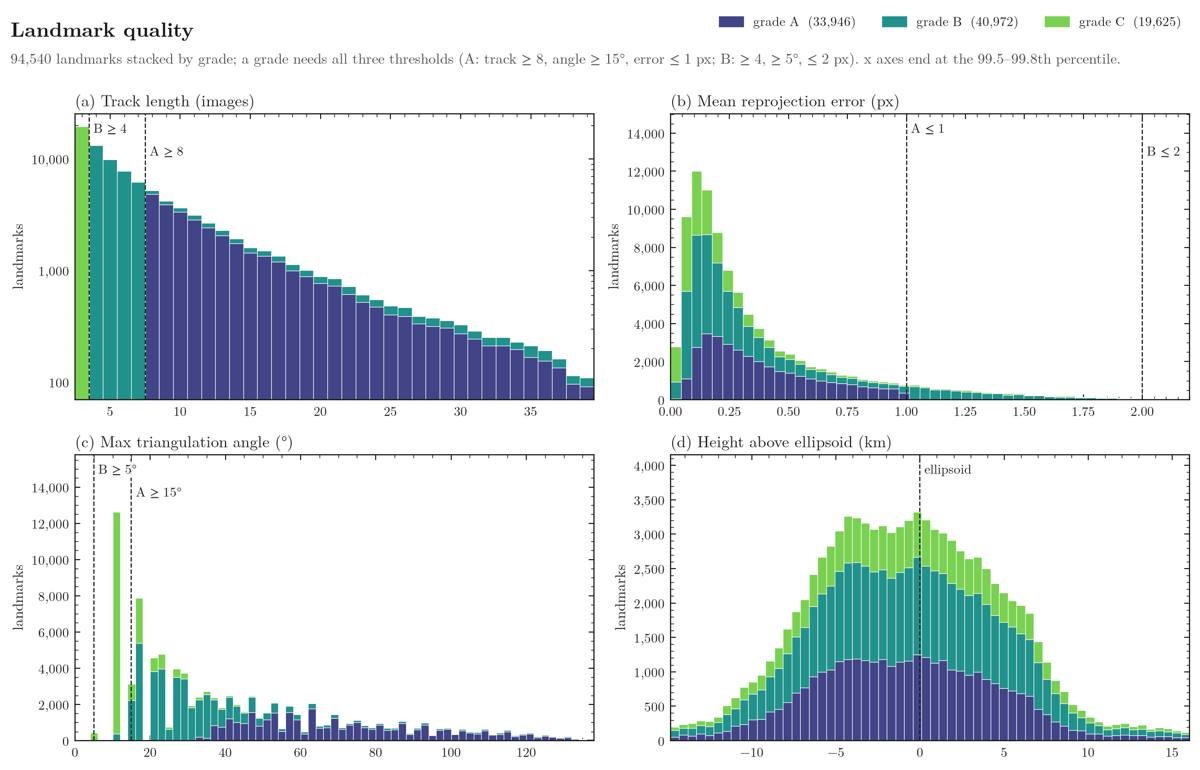

**10_radius_vs_latitude**: height against latitude as a log-density hexbin, with the median and quartiles per 5° band

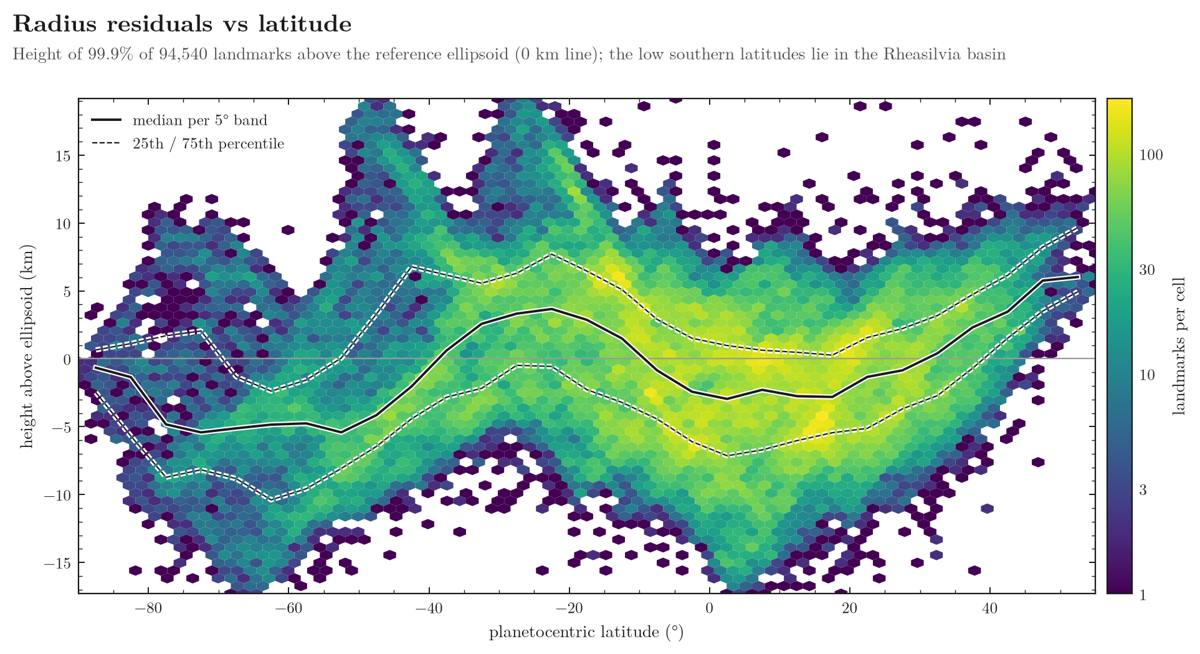

**11_landmark_chips**: image patches of grade A landmarks across their views

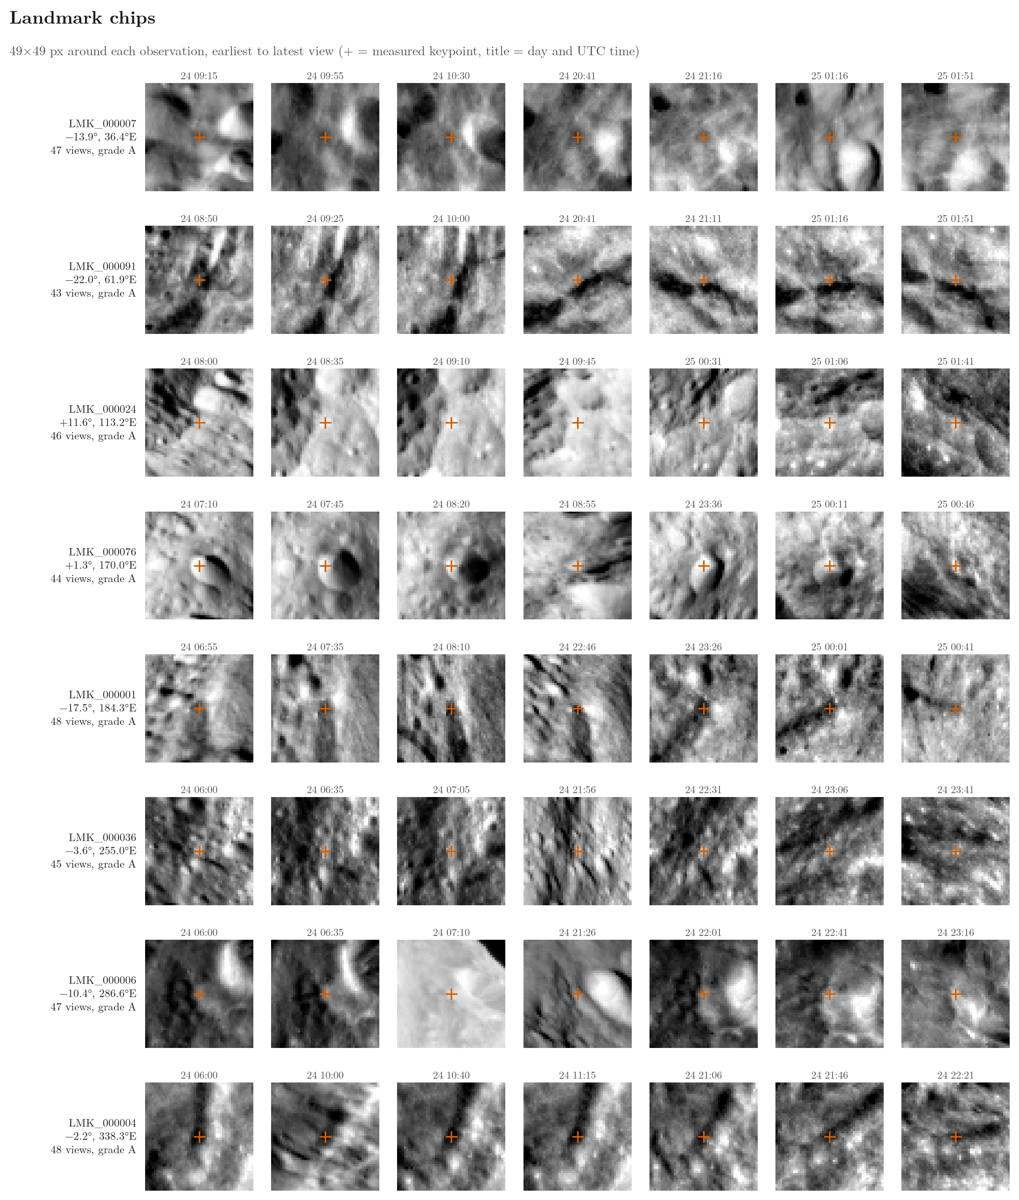

In [15]:
SECTION = "figures"
import matplotlib as mpl
from PIL import Image as PILImage

from asteroid_colmap import plots
from asteroid_colmap.workspace import Workspace

if FULL and (WORKDIR / "metadata.csv").exists():
    before = dict(mpl.rcParams)
    written = plots.make_all(Workspace(WORKDIR), ds, interactive=False)
    changed = [k for k, val in mpl.rcParams.items() if before.get(k) != val]
    check("make_all leaves matplotlib's rcParams unchanged", not changed, ", ".join(changed[:5]))
    pngs = [p for p in written if p.suffix == ".png"]
    check("all 11 figures drawn", len(pngs) == 11, f"{len(pngs)} PNGs in {rel(WORKDIR / 'plots')}")
else:
    pngs = sorted((EXAMPLE / "plots").glob("*.png"))
    print(f"no full workspace: showing the {len(pngs)} committed figures from {rel(EXAMPLE / 'plots')}")

NOTES = {
    "01_montage": "prepared input frames, evenly spaced in time",
    "02_geometry": "sub-spacecraft ground track with the polar-night band; range and phase against hours since sequence start",
    "03_orientation_check": "observed silhouettes against the label-predicted lit ellipsoid, for every flip",
    "04_features": "landmark observations on the best-connected image of each sequence",
    "05_covisibility": "landmarks shared by every image pair",
    "06_alignment": "per image, relative to the label poses: position residual along the line of sight and sideways, pointing difference at the boresight and at the landmarks, and twist",
    "07_pointcloud": "four orthographic globe views of the landmarks, coloured by height",
    "08_landmark_map": "equirectangular map by height, curated subset by track length, south-polar view of Rheasilvia",
    "09_quality": "track length, reprojection error, triangulation angle and height, stacked by grade",
    "10_radius_vs_latitude": "height against latitude as a log-density hexbin, with the median and quartiles per 5° band",
    "11_landmark_chips": "image patches of grade A landmarks across their views",
}


def show(path, note=None, title=None, max_px=1200, width=900):
    im = PILImage.open(path).convert("RGB")
    im.thumbnail((max_px, max_px))
    buf = io.BytesIO()
    im.save(buf, "JPEG", quality=72, optimize=True)
    display(Markdown(f"**{title or path.stem}**: {NOTES.get(path.stem, '') if note is None else note}"))
    display(Image(data=buf.getvalue(), format="jpeg", width=width))


for p in pngs:
    show(p)

## 13. Interactive point cloud

A rotatable 3-D view of a sample of the curated landmarks, coloured by height. The full-size
version is `plots/pointcloud.html`, written by `asteroid-colmap plot` when plotly is installed.

In [16]:
SECTION = "interactive"
try:
    import plotly.io as pio
except ImportError:
    print("plotly is not installed: pip install -e '.[interactive]'")
else:
    pio.renderers.default = "plotly_mimetype"
    fig = plots.interactive_figure(curated, max_points=2000)
    n_points = len(fig.data[0].x)
    check("interactive_figure samples the non-outliers", n_points == min(2000, int((~curated.outlier).sum())), f"{n_points:,} points")
    fig.show()

✓ interactive_figure samples the non-outliers (2,000 points)


## 14. Matching new images with NCC

The catalog becomes a navigation map in two steps.

* **Maplets** (`asteroid-colmap templates`). Each curated landmark gets a maplet: a 31 × 31 grid
  of heights on the landmark's tangent plane, at the catalog's median ground sample distance
  (0.492 km), plus its brightness in up to four catalog images. The four views are picked to
  spread the Sun directions as widely as possible.
* **Matching** (`asteroid-colmap match`). For each new image, every visible landmark is rendered as
  the camera should see it, from the reference view whose Sun direction is closest (within 30°),
  and searched for by normalized cross-correlation (NCC). There are three passes:
  1. 160 high-contrast landmarks searched over ±20 px, to remove the label's pointing error;
  2. every visible landmark over ±6 px, followed by an attitude fit with outlier rejection. A match
     is accepted when its NCC peak is at least 0.8 and leads the runner-up peak by at least 0.1;
  3. a new rendering at the fitted attitude, a search over ±3 px, and a second fit.

  The position stays at the label's. Each image gets an attitude correction: the boresight
  offset (du, dv) in pixels and a twist. Section 15 estimates the position as well.

There are two runs:

| Run | Images | What it tests |
|---|---|---|
| `opnav022` | 15 optical-navigation frames from 2011-07-31, at about 4,000 km, a week after RC3. None of them is in the catalog. | Matching images the catalog has never seen |
| `catalog` | The 130 catalog images. Each one is matched without its own reference views. | Agreement with the COLMAP poses |

The notebook reads `$WORKDIR/navigation/<run>`, or else the copies in
`examples/vesta_rc3/navigation`. Those copies leave out `matches.csv` (8 MB and 95 MB), and
`catalog/templates.npz` (74 MB) is never committed, so the maplet and per-match checks need a
workspace.

The checks:

* **Maplets:** every maplet belongs to a curated landmark; each has 1–4 views and 31 × 31 samples
  at the median curated GSD; more than 85 % of the curated landmarks have one.
* **Per run:**
  * every image has a pose, with at least 100 inliers;
  * the post-fit RMS is below 0.5 px and at least 5 times below the pre-fit RMS;
  * the shift found by pass 1 matches the final boresight correction to within 0.5 px. The two
    have opposite signs: the shift moves the predicted landmarks, the correction moves the
    boresight;
  * the counts in `summary.json` match `poses.csv`.
* **From `matches.csv`:**
  * accepted matches have a position and NCC ≥ 0.8;
  * inliers are a subset of the accepted matches;
  * the per-image counts and the post-fit RMS can be recomputed from the residual columns.
* **Catalog run:** the corrected attitude reprojects the landmarks within 0.2 px of the
  COLMAP pose.

In [17]:
SECTION = "ncc matching"
from asteroid_colmap.ncc import Templates

if RUN_NAVIGATION:
    from asteroid_colmap import cli

    for argv in (["templates"], ["match", "--name", "opnav022", "--source", "vesta-opnav"],
                 ["match", "--name", "catalog", "--catalog-images"],
                 ["pose", "--name", "opnav022"], ["pose", "--name", "catalog"]):
        status = cli.main(argv + ["-w", str(WORKDIR)])
        check(f"asteroid-colmap {' '.join(argv)}", status == 0, f"exit status {status}")
else:
    print("RUN_NAVIGATION is False: using the existing results")


def nav_dir(name):
    run = WORKDIR / "navigation" / name
    return run if (run / "poses.csv").exists() else EXAMPLE / "navigation" / name


NAV = {name: nav_dir(name) for name in NAV_RUNS}
for name, d in NAV.items():
    has_matches = (d / "matches.csv").exists()
    print(f"{name:9s}", rel(d), "" if has_matches else "(no matches.csv: per-match checks skipped)")

TPL = CAT / "templates.npz"
if TPL.exists():
    t = Templates.load(TPL)
    check("maplets belong to distinct curated landmarks",
          np.isin(t.landmark_id, curated.landmark_id).all() and len(set(t.landmark_id)) == len(t), f"{len(t):,} maplets")
    check("1 to 4 reference views per maplet", 1 <= t.num_views.min() and t.num_views.max() <= 4,
          f"mean {t.num_views.mean():.2f}")
    gsd = round(float(curated.gsd_km.median()), 3)
    check("31 × 31 samples at the median curated GSD", t.size == 31 and t.maplet.shape[-2:] == (31, 31)
          and t.spacing_km == gsd, f"{t.spacing_km:.3f} km")
    check("more than 85 % of the curated landmarks have a maplet", len(t) > 0.85 * len(curated),
          f"{len(t):,} of {len(curated):,} ({len(t) / len(curated):.1%})")
else:
    print(f"{rel(TPL)} not found: maplet checks skipped")

RUN_NAVIGATION is False: using the existing results
opnav022  ./work/navigation/opnav022 
catalog   ./work/navigation/catalog 
✓ maplets belong to distinct curated landmarks (6,825 maplets)
✓ 1 to 4 reference views per maplet (mean 3.93)
✓ 31 × 31 samples at the median curated GSD (0.492 km)
✓ more than 85 % of the curated landmarks have a maplet (6,825 of 7,480 (91.2%))


In [18]:
rows = {}
for name, d in NAV.items():
    meta = pd.read_csv(d / "metadata.csv")
    poses = pd.read_csv(d / "poses.csv")
    m = json.loads((d / "summary.json").read_text())["matching"]
    ok = poses[poses.success]
    check(f"{name}: every image has a pose", len(poses) == len(meta) and poses.success.all(), f"{len(ok)} of {len(meta)}")
    check(f"{name}: at least 100 inliers per image", ok.num_inliers.min() >= 100,
          f"min {ok.num_inliers.min():,}, median {ok.num_inliers.median():,.0f}")
    gain = ok.prefit_rms_px / ok.postfit_rms_px
    check(f"{name}: post-fit RMS < 0.5 px and 5 × below pre-fit", ok.postfit_rms_px.max() < 0.5 and gain.min() > 5,
          f"max {ok.postfit_rms_px.max():.3f} px; pre/post at least {gain.min():.1f}")
    gap = np.hypot(ok.coarse_shift_u_px + ok.du_px, ok.coarse_shift_v_px + ok.dv_px)
    check(f"{name}: pass-1 shift = −(du, dv)", gap.max() < 0.5,
          f"max |shift + correction| {gap.max():.2f} px, median correction {np.hypot(ok.du_px, ok.dv_px).median():.2f} px")
    check(f"{name}: summary.json counts", m["num_images_with_pose"] == len(ok)
          and m["num_searched"] == poses.num_searched.sum() and m["num_accepted"] == poses.num_accepted.sum()
          and m["num_inliers"] == poses.num_inliers.sum(),
          f"{m['num_searched']:,} searched, {m['num_accepted']:,} accepted, {m['num_inliers']:,} inliers")

    if (d / "matches.csv").exists():
        mt = pd.read_csv(d / "matches.csv")
        acc = mt[mt.accepted]
        min_ncc = m["options"]["min_ncc"]
        check(f"{name}: accepted matches have a position and NCC ≥ {min_ncc}",
              (np.isfinite(acc.u) & np.isfinite(acc.v) & (acc.ncc >= min_ncc)).all(), f"{len(acc):,} of {len(mt):,}")
        check(f"{name}: inliers ⊂ accepted", mt.accepted[mt.inlier].all(), f"{int(mt.inlier.sum()):,} inliers")
        inl = mt[mt.inlier]
        by = mt.groupby("image")
        counts = pd.DataFrame({"num_searched": by.size(), "num_accepted": by.accepted.sum(), "num_inliers": by.inlier.sum()})
        counts = counts.reindex(poses.image, fill_value=0).astype(int)
        rms = np.sqrt((inl.residual_u_px**2 + inl.residual_v_px**2).groupby(inl.image).mean()).reindex(ok.image)
        check(f"{name}: per-image counts and post-fit RMS from matches.csv",
              (counts.to_numpy() == poses[counts.columns].to_numpy()).all()
              and np.allclose(rms, ok.postfit_rms_px, rtol=1e-6), f"median post-fit RMS {rms.median():.3f} px")

    if "sfm_estimate_rms_px" in ok:
        check(f"{name}: corrected attitude against the COLMAP pose",
              ok.sfm_estimate_rms_px.max() < 0.2 and ok.sfm_measurement_rms_px.max() < 0.35,
              f"landmarks reproject {ok.sfm_estimate_rms_px.median():.3f} px from the COLMAP projections "
              f"(max {ok.sfm_estimate_rms_px.max():.3f}); NCC measurements {ok.sfm_measurement_rms_px.median():.3f} px; "
              f"label poses {ok.sfm_apriori_rms_px.median():.2f} px")

    rows[name] = {
        "images with a pose": f"{len(ok)} of {len(poses)}",
        "searched / accepted / inliers": f"{m['num_searched']:,} / {m['num_accepted']:,} / {m['num_inliers']:,}",
        "inliers per image (median)": f"{m['median_inliers_per_image']:,.0f}",
        "median NCC of the inliers": f"{m['median_ncc']:.3f}",
        "RMS at the label pose → after the fit": f"{m['median_prefit_rms_px']:.2f} → {m['median_postfit_rms_px']:.3f} px",
        "attitude correction (median)": f"{m['median_correction_arcsec']:.0f}″ ({m['median_correction_px']:.1f} px)",
    }
display(pd.DataFrame(rows))

✓ opnav022: every image has a pose (15 of 15)
✓ opnav022: at least 100 inliers per image (min 941, median 988)
✓ opnav022: post-fit RMS < 0.5 px and 5 × below pre-fit (max 0.345 px; pre/post at least 14.8)
✓ opnav022: pass-1 shift = −(du, dv) (max |shift + correction| 0.12 px, median correction 5.34 px)
✓ opnav022: summary.json counts (19,708 searched, 15,588 accepted, 14,729 inliers)
✓ opnav022: accepted matches have a position and NCC ≥ 0.8 (15,588 of 19,708)
✓ opnav022: inliers ⊂ accepted (14,729 inliers)
✓ opnav022: per-image counts and post-fit RMS from matches.csv (median post-fit RMS 0.339 px)
✓ catalog: every image has a pose (130 of 130)
✓ catalog: at least 100 inliers per image (min 953, median 1,365)
✓ catalog: post-fit RMS < 0.5 px and 5 × below pre-fit (max 0.328 px; pre/post at least 5.4)
✓ catalog: pass-1 shift = −(du, dv) (max |shift + correction| 0.21 px, median correction 2.41 px)
✓ catalog: summary.json counts (233,090 searched, 182,030 accepted, 176,455 inliers)
✓ c

,opnav022,catalog
images with a pose,15 of 15,130 of 130
searched / accepted / inliers,"19,708 / 15,588 / 14,729","233,090 / 182,030 / 176,455"
inliers per image (median),988,"1,365"
median NCC of the inliers,0.976,0.965
RMS at the label pose → after the fit,5.37 → 0.339 px,2.43 → 0.270 px
attitude correction (median),109″ (5.3 px),53″ (2.4 px)


#### opnav022: 15 new images from 2011-07-31, a week after RC3 (not in the catalog)

**opnav022/01_matches**: every searched landmark on one image coloured by NCC (rejected ones in grey), and a true-scale zoom with arrows from the a priori to the measured position

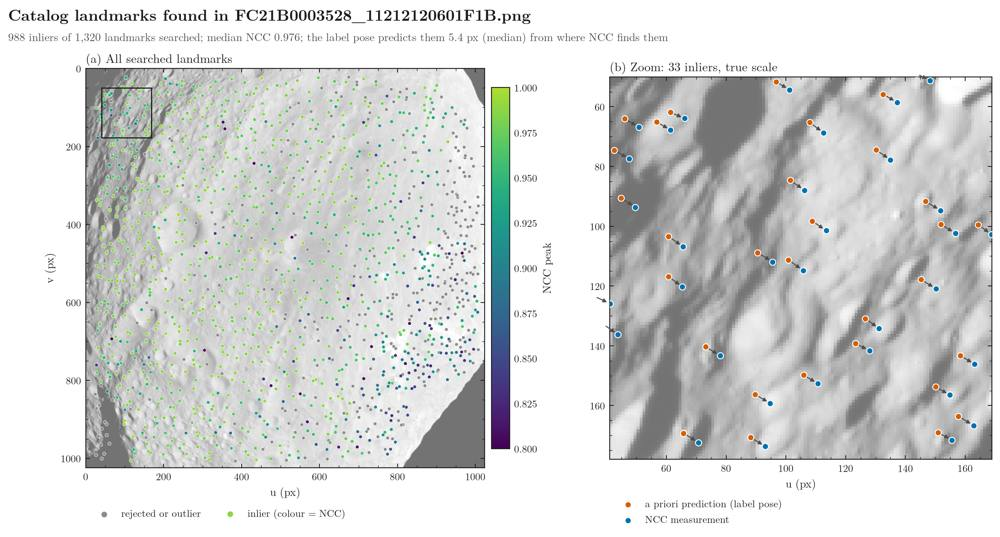

**opnav022/02_chips**: eight landmarks across the NCC range: the maplet, the rendering at the estimated pose, and the image at the estimated and at the a priori pose

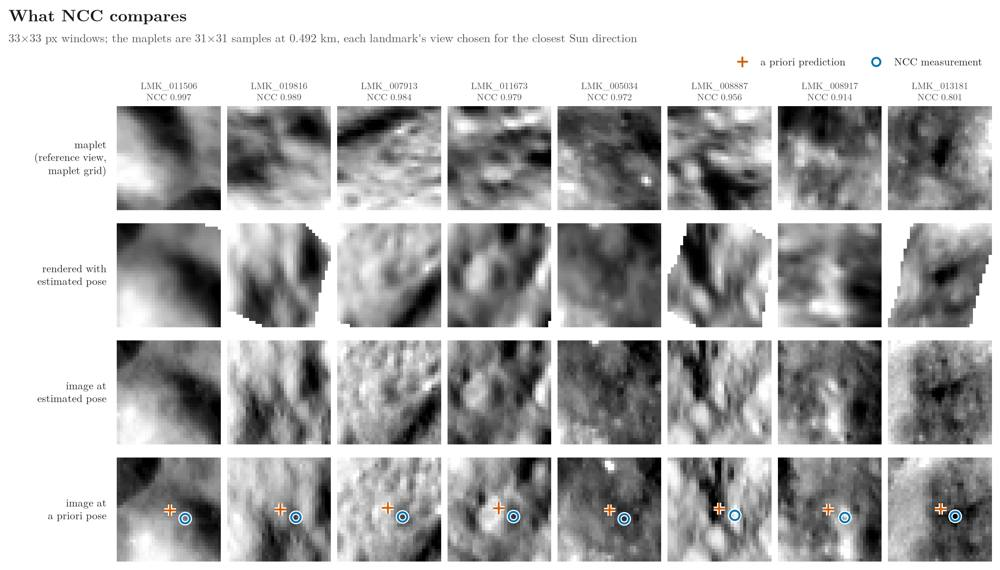

**opnav022/03_residuals**: measured − a priori (a common shift is a pointing error), measured − estimated, and the density of the post-fit residuals

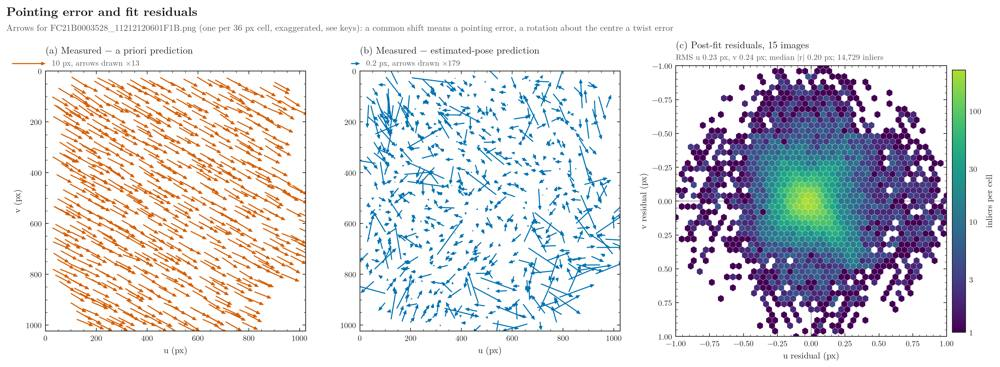

**opnav022/04_navigation**: per image: the boresight correction, the pre-fit and post-fit RMS, the landmarks searched, accepted and kept, and the median NCC

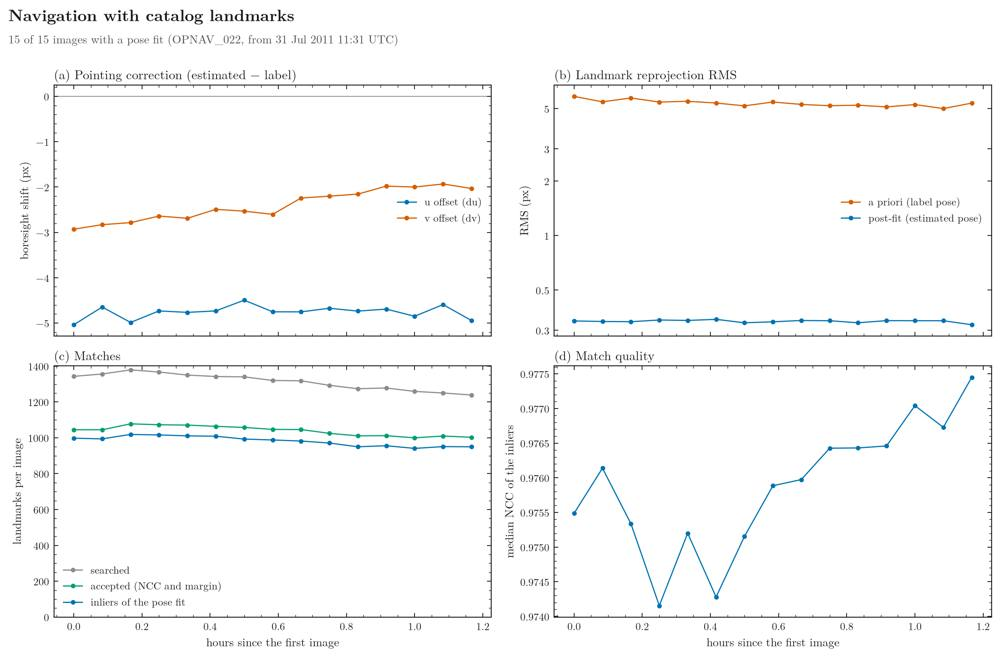

#### catalog: the 130 catalog images, each matched without its own reference views

**catalog/01_matches**: every searched landmark on one image coloured by NCC (rejected ones in grey), and a true-scale zoom with arrows from the a priori to the measured position

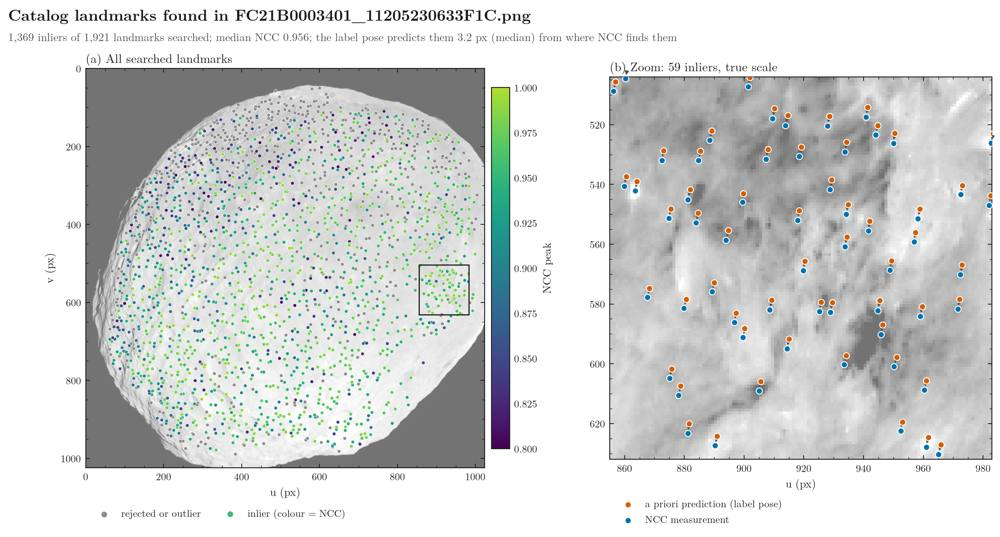

**catalog/02_chips**: eight landmarks across the NCC range: the maplet, the rendering at the estimated pose, and the image at the estimated and at the a priori pose

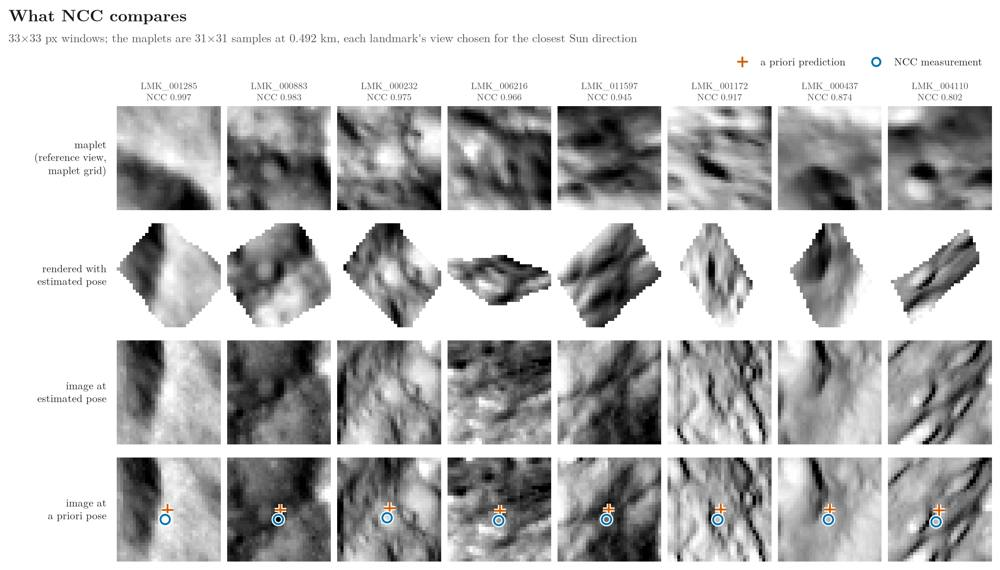

**catalog/03_residuals**: measured − a priori (a common shift is a pointing error), measured − estimated, and the density of the post-fit residuals

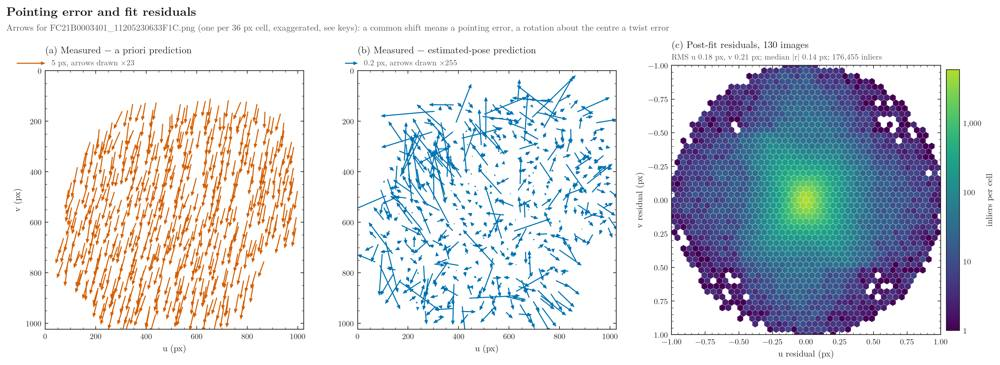

**catalog/04_navigation**: per image: the boresight correction, the pre-fit and post-fit RMS, the landmarks searched, accepted and kept, and the median NCC

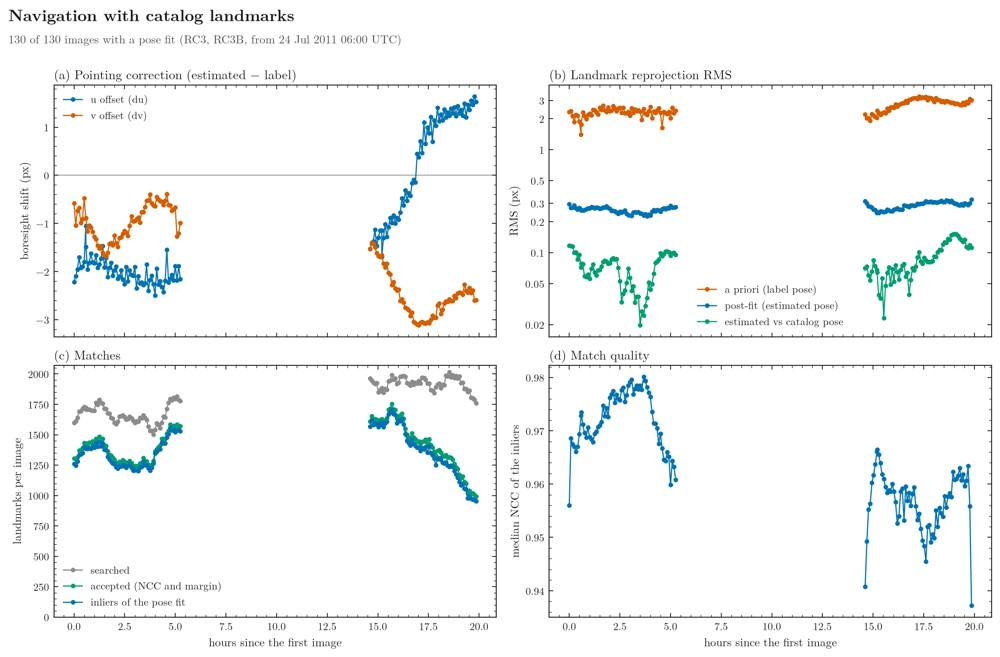

In [19]:
NAV_NOTES = {
    "01_matches": "every searched landmark on one image coloured by NCC (rejected ones in grey), and a "
                  "true-scale zoom with arrows from the a priori to the measured position",
    "02_chips": "eight landmarks across the NCC range: the maplet, the rendering at the estimated pose, "
                "and the image at the estimated and at the a priori pose",
    "03_residuals": "measured − a priori (a common shift is a pointing error), measured − estimated, "
                    "and the density of the post-fit residuals",
    "04_navigation": "per image: the boresight correction, the pre-fit and post-fit RMS, the landmarks "
                     "searched, accepted and kept, and the median NCC",
}
for name, d in NAV.items():
    display(Markdown(f"#### {name}: {NAV_RUNS[name]}"))
    for stem, note in NAV_NOTES.items():
        show(d / "plots" / f"{stem}.png", note, title=f"{name}/{stem}", max_px=1000)

## 15. Relative pose

`asteroid-colmap pose` estimates each image's position and attitude relative to Vesta from its
NCC matches alone, without the label pose:

1. POSIT inside RANSAC (12-point samples, 2 px threshold) gives a first pose and the inliers.
2. A robust least-squares fit of the 6 parameters (3 for rotation, 3 for position), with
   σ = 0.3 px per measurement, gives the pose and its 6 × 6 covariance. When the post-fit χ²/dof
   exceeds 1, the covariance is scaled up by it.
3. A weighted polynomial in J2000 is fitted to the positions of each sequence (degree 2 by
   default). This smooths the arc, and its χ²/dof tests whether the formal covariances match
   the scatter.

Each pose is compared with the label pose, with the attitude-only fit of section 14, and, for
the catalog images, with the COLMAP pose.

**What is well determined.** The range comes from the apparent size of the landmark pattern and is
known to about 0.1 km at 4,000–5,500 km. Sideways, a small shift of the camera looks almost like a
small rotation. So the east and north 1σ are 3–4 times larger (0.4–0.5 km), and the lateral error
trades against the attitude error. The pixel where the body centre appears (`target_u_px`,
`target_v_px`) stays well determined: its 1σ is below 0.1 px.

The checks:

* **Bookkeeping:** the range, the J2000 position and the range/east/north 1σ can be recomputed
  from the body-fixed position and its covariance, and the covariance is positive definite.
* **Weak mode:** the range is the best-determined direction in every image.
* **Fit quality:**
  * with 3 more parameters, the RMS is at most 0.02 px above the attitude-only fit's;
  * the label pose fits the matches at least 5 times worse than the estimated pose;
  * the position is within 0.1 % of the range of the label's.
* **Body centre:** the 1σ of the body-centre pixel is below 0.2 px.
* **Smoothed arc:**
  * its median 1σ is below a single image's;
  * `opnav022`: χ²/dof is between 0.5 and 2;
  * `catalog`: the χ²/dof excess disappears with a degree-8 arc (below 1.5).
* **`summary.json`:** its values match the CSV files.
* **Catalog run:** the estimate agrees with the COLMAP pose, to within 0.5 px for the body-centre
  pixel and 0.1 % of the range for the position.

✓ opnav022: range, J2000 position and 1σ recomputed; covariance positive definite (smallest eigenvalue 0.0088 km²)
✓ opnav022: range is the best-determined direction (median 1σ range / east / north 0.099 / 0.370 / 0.360 km)
✓ opnav022: 6-parameter fit no worse than the attitude-only fit (median RMS 0.327 vs 0.339 px)
✓ opnav022: label pose fits the matches over 5 × worse (median RMS 5.37 vs 0.327 px)
✓ opnav022: position within 0.1 % of the range of the label's (max 3.31 km (0.082%))
✓ opnav022: body-centre pixel 1σ < 0.2 px (max 0.086 px)
✓ opnav022: smoothed arc has a smaller 1σ than single images (median 0.038 / 0.141 / 0.137 vs 0.099 / 0.370 / 0.360 km)
✓ opnav022: arc χ²/dof between 0.5 and 2 (1.00 at degree 2)
✓ opnav022: summary.json values 
✓ catalog: range, J2000 position and 1σ recomputed; covariance positive definite (smallest eigenvalue 0.0134 km²)
✓ catalog: range is the best-determined direction (median 1σ range / east / north 0.139 / 0.492 / 0.507 km)
✓ catalog: 6-parame

,opnav022,catalog
images solved,15 of 15,130 of 130
median RMS,0.327 px,0.265 px
"1σ range / east / north, single image",0.099 / 0.370 / 0.360 km,0.139 / 0.492 / 0.507 km
"1σ range / east / north, smoothed arc",0.038 / 0.141 / 0.137 km,0.026 / 0.090 / 0.092 km
RMS estimate − label,0.63 / 1.48 / 2.01 km,1.07 / 0.70 / 1.54 km
RMS estimate − COLMAP,–,0.33 / 0.60 / 0.73 km
attitude − label (median),225″,69″
attitude − attitude-only fit (median),134″,54″
arc χ²/dof (degree 2),OPNAV_022 1.00,"RC3 3.43, RC3B 4.01"


**opnav022/05_relative_pose**: range, east and north minus the label with ±1σ and the smoothed arc; attitude minus the label for both fits; RMS for the label, attitude-only and 6-parameter fits; scatter against the formal 1σ

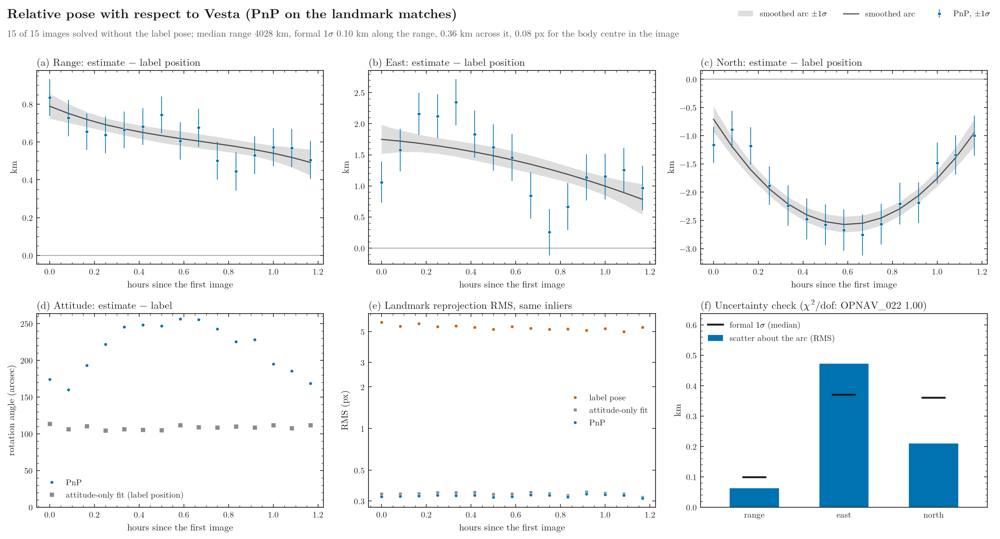

**catalog/05_relative_pose**: range, east and north minus the label with ±1σ and the smoothed arc; attitude minus the label for both fits; RMS for the label, attitude-only and 6-parameter fits; scatter against the formal 1σ

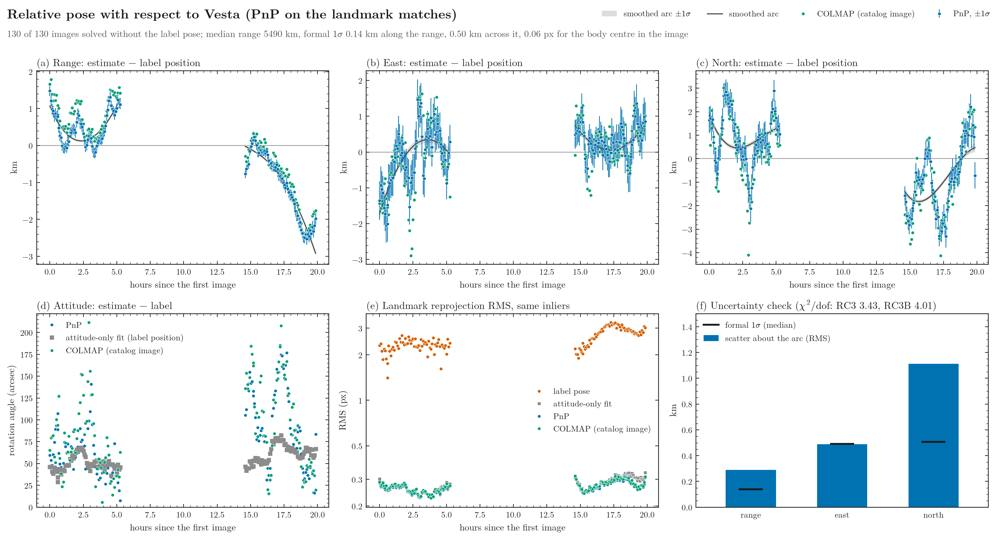

In [20]:
SECTION = "relative pose"
import datetime as dt

from asteroid_colmap.pose import fit_trajectory, local_axes

SIG = ["sigma_range_km", "sigma_east_km", "sigma_north_km"]
COV = ["cov_xx_km2", "cov_xy_km2", "cov_xz_km2", "cov_xy_km2", "cov_yy_km2", "cov_yz_km2",
       "cov_xz_km2", "cov_yz_km2", "cov_zz_km2"]


def fmt(values, spec=".2f"):
    return " / ".join(f"{v:{spec}}" for v in values)


rows = {}
for name, d in NAV.items():
    r = pd.read_csv(d / "relative_pose.csv")
    tr = pd.read_csv(d / "trajectory.csv")
    s = json.loads((d / "summary.json").read_text())["relative_pose"]
    ok = r[r.success]

    C = ok[["x_km", "y_km", "z_km"]].to_numpy()
    P = ok[COV].to_numpy().reshape(-1, 3, 3)
    E = np.stack([local_axes(c) for c in C])
    sig = np.sqrt(np.diagonal(E @ P @ E.transpose(0, 2, 1), axis1=1, axis2=2))
    j2000 = np.stack([geo.body_from_j2000(VESTA, dt.datetime.fromisoformat(u)).T @ c for u, c in zip(ok.utc, C)])
    eig = np.linalg.eigvalsh(P).min()
    check(f"{name}: range, J2000 position and 1σ recomputed; covariance positive definite",
          np.abs(np.linalg.norm(C, axis=1) - ok.range_km).max() < 1e-6
          and np.abs(j2000 - ok[["j2000_x_km", "j2000_y_km", "j2000_z_km"]].to_numpy()).max() < 1e-6
          and np.allclose(sig, ok[SIG], rtol=1e-6) and eig > 0, f"smallest eigenvalue {eig:.4f} km²")
    lateral = np.minimum(ok.sigma_east_km, ok.sigma_north_km)
    check(f"{name}: range is the best-determined direction", (ok.sigma_range_km < lateral).all(),
          f"median 1σ range / east / north {fmt(ok[SIG].median(), '.3f')} km")
    check(f"{name}: 6-parameter fit no worse than the attitude-only fit", (ok.rms_px <= ok.ncc_rms_px + 0.02).all(),
          f"median RMS {ok.rms_px.median():.3f} vs {ok.ncc_rms_px.median():.3f} px")
    gain = ok.label_rms_px / ok.rms_px
    check(f"{name}: label pose fits the matches over 5 × worse", gain.min() > 5,
          f"median RMS {ok.label_rms_px.median():.2f} vs {ok.rms_px.median():.3f} px")
    frac = ok.position_minus_label_km / ok.range_km
    check(f"{name}: position within 0.1 % of the range of the label's", frac.max() < 1e-3,
          f"max {ok.position_minus_label_km.max():.2f} km ({frac.max():.3%})")
    st = np.hypot(ok.sigma_target_u_px, ok.sigma_target_v_px)
    check(f"{name}: body-centre pixel 1σ < 0.2 px", st.max() < 0.2, f"max {st.max():.3f} px")

    smooth, single = tr[SIG].median().to_numpy(), ok[SIG].median().to_numpy()
    check(f"{name}: smoothed arc has a smaller 1σ than single images", (smooth < single).all(),
          f"median {fmt(smooth, '.3f')} vs {fmt(single, '.3f')} km")
    chi2 = tr.groupby("sequence").chi2_dof.first()
    if name == "opnav022":
        check(f"{name}: arc χ²/dof between 0.5 and 2", chi2.between(0.5, 2.0).all(), f"{fmt(chi2)} at degree 2")
    else:
        deg8 = fit_trajectory(r, VESTA, degree=8).groupby("sequence").chi2_dof.first()
        check(f"{name}: the χ²/dof excess is smooth", (deg8 < 1.5).all(),
              f"{', '.join(chi2.index)}: {fmt(chi2)} at degree 2, {fmt(deg8.reindex(chi2.index))} at degree 8")

    def rms(col):
        return float(np.sqrt(np.mean(ok[col].dropna() ** 2)))

    keys = ("range", "east", "north")
    check(f"{name}: summary.json values", np.isclose(s["median_rms_px"], ok.rms_px.median())
          and all(np.isclose(s[f"rms_{k}_minus_label_km"], rms(f"{k}_minus_label_km")) for k in keys)
          and set(s["trajectory"]["chi2_dof"]) == set(chi2.index)
          and all(np.isclose(s["trajectory"]["chi2_dof"][q], chi2[q]) for q in chi2.index))

    row = {
        "images solved": f"{len(ok)} of {len(r)}",
        "median RMS": f"{ok.rms_px.median():.3f} px",
        "1σ range / east / north, single image": f"{fmt(single, '.3f')} km",
        "1σ range / east / north, smoothed arc": f"{fmt(smooth, '.3f')} km",
        "RMS estimate − label": f"{fmt(rms(f'{k}_minus_label_km') for k in keys)} km",
        "RMS estimate − COLMAP": "–",
        "attitude − label (median)": f"{ok.attitude_minus_label_arcsec.median():.0f}″",
        "attitude − attitude-only fit (median)": f"{ok.attitude_minus_ncc_arcsec.median():.0f}″",
        "arc χ²/dof (degree 2)": ", ".join(f"{q} {v:.2f}" for q, v in chi2.items()),
    }
    if "position_minus_sfm_km" in ok:
        pix = np.hypot(ok.target_du_sfm_px, ok.target_dv_sfm_px)
        frac = ok.position_minus_sfm_km / ok.range_km
        check(f"{name}: agrees with the COLMAP pose", pix.max() < 0.5 and frac.max() < 1e-3,
              f"body-centre pixel median {pix.median():.3f} px (max {pix.max():.2f}); position max "
              f"{ok.position_minus_sfm_km.max():.2f} km ({frac.max():.3%}); attitude median {ok.attitude_minus_sfm_arcsec.median():.0f}″")
        row["RMS estimate − COLMAP"] = f"{fmt(rms(f'{k}_minus_sfm_km') for k in keys)} km"
    rows[name] = row
display(pd.DataFrame(rows))

for name, d in NAV.items():
    show(d / "plots" / "05_relative_pose.png",
         "range, east and north minus the label with ±1σ and the smoothed arc; attitude minus the label for both "
         "fits; RMS for the label, attitude-only and 6-parameter fits; scatter against the formal 1σ",
         title=f"{name}/05_relative_pose", max_px=1000)

**Reading the comparisons.**

* **Against the label.** The estimate differs from the label by 1.5–3 km in `opnav022` and up to
  3 km in `catalog` (median about 2 km). The formal 1σ is 0.1–0.5 km, and the label pose
  predicts the measured landmarks 6–18 times worse than the estimate. So these differences are
  mostly label error.
* **Against COLMAP.** For the catalog images, the estimate agrees with COLMAP to 0.3 km in range
  and about 0.7 km sideways (RMS). The sideways part is the weak mode: it comes with a median
  attitude difference of 35″.
* **The χ²/dof of the arc.** For `opnav022` (1.2 hours), the χ²/dof of the quadratic arc is
  about 1, so the formal covariances match the scatter. RC3 and RC3B each last 5.25 hours,
  about one Vesta rotation. Their χ²/dof is 3.2 and 3.9 with a quadratic arc, and falls to 1.2
  and 0.8 with a degree-8 arc. Over 5 hours the spacecraft's path is close to a straight line, so
  the higher-degree terms are not following the spacecraft. They absorb an error in the
  estimates that changes smoothly as different sides of Vesta come into view, most likely from
  the catalog itself. In the range and north directions the arc residuals are about twice the
  single-image 1σ; east is close to 1σ. Over a full rotation, the range and north 1σ should
  therefore be doubled.

## 16. Summary

In [21]:
SECTION = "summary"
checks = pd.DataFrame(CHECKS)
counts = checks.status.value_counts().reindex(["pass", "FAIL"], fill_value=0)
print(f"{counts['pass']} passed, {counts['FAIL']} failed")
display(checks)
assert counts["FAIL"] == 0, "some checks failed: see the table above"

104 passed, 0 failed


,section,check,status,detail
0,setup,asteroid_colmap is imported from this repository,pass,./src/asteroid_colmap
1,unit tests,pytest suite,pass,59 passed in 2.01s
2,camera,pixel_rays returns unit vectors,pass,
3,camera,"project(pixel_rays(u, v)) = (u, v)",pass,"max 3.0e-09 px over 10,000 random pixels"
4,camera,horizontal field of view,pass,5.468° (nominal 5.471°)
5,camera,radial distortion is sub-pixel,pass,+0.62 px = 0.086 % at the corner
6,camera,focal length / width exceeds COLMAP's default limit of 10,pass,10.47
7,camera,the pipeline raises the limit above it,pass,Mapper.max_focal_length_ratio = 20.9
8,labels,QUATERNION is a unit 4-vector,pass,
9,labels,"START_TIME is in RC3 (2011, day 205)",pass,
